El objetivo de este análisis es realizar un análisis exploratorio más exhaustivo de los datos, una vez que se dispone del conjunto completo que se utilizará.

In [10]:
import pandas as pd

df = pd.read_parquet('../data/processed/dataset_solar_2023_2024_v1.parquet')
df.head()

,ano,mes_sin,mes_cos,dia,hora_sin,hora_cos,minuto,fecha,ghi,dni,dhi,elevacion_solar,temperatura,velocidad_viento,humedad_relativa,direccion_viento_sin,direccion_viento_cos,codigo_ghi,codigo_dni,codigo_dhi
0,2023,0.0,1.0,1,0.0,1.0,0,2023-01-01 00:00:00,0.0,0.0,0.0,-74.485290,10.0,1.050,77.0,0.884988,-0.465615,0,0,0
1,2023,0.0,1.0,1,0.0,1.0,1,2023-01-01 00:01:00,0.0,0.0,0.0,-74.564907,10.0,1.333,77.0,-0.748956,0.662620,0,0,0
2,2023,0.0,1.0,1,0.0,1.0,2,2023-01-01 00:02:00,0.0,0.0,0.0,-74.641937,10.0,1.100,77.0,-0.972031,-0.234854,0,0,0
3,2023,0.0,1.0,1,0.0,1.0,3,2023-01-01 00:03:00,0.0,0.0,0.0,-74.716341,10.0,1.333,77.0,-0.937179,0.348850,0,0,0
4,2023,0.0,1.0,1,0.0,1.0,4,2023-01-01 00:04:00,0.0,0.0,0.0,-74.788081,10.0,1.058,77.0,-0.443587,0.896231,0,0,0


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1052640 entries, 0 to 1052639
Data columns (total 20 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   ano                   1052640 non-null  int64         
 1   mes_sin               1052640 non-null  float64       
 2   mes_cos               1052640 non-null  float64       
 3   dia                   1052640 non-null  int64         
 4   hora_sin              1052640 non-null  float64       
 5   hora_cos              1052640 non-null  float64       
 6   minuto                1052640 non-null  int64         
 7   fecha                 1052640 non-null  datetime64[us]
 8   ghi                   1040772 non-null  float64       
 9   dni                   1040772 non-null  float64       
 10  dhi                   1040772 non-null  float64       
 11  elevacion_solar       1052640 non-null  float64       
 12  temperatura           957464 non-null   float64      

In [12]:
print(df['fecha'].min(), df['fecha'].max())
print('Duplicados:', df['fecha'].duplicated().sum())

expected = {
    2023: 365 * 24 * 60,
    2024: 366 * 24 * 60
}

print("Año, Muestras, Muestras esperadas, Diferencias entre muestras reales y esperadas")
for year, expected_rows in expected.items():
    real_rows = len(df[df['ano'] == year])
    print(year, real_rows, expected_rows, real_rows - expected_rows)

2023-01-01 00:00:00 2024-12-31 23:59:00
Duplicados: 0
Año, Muestras, Muestras esperadas, Diferencias entre muestras reales y esperadas
2023 525600 525600 0
2024 527040 527040 0


Se tiene un dataset con más de 1 millón de mediciones y 20 variables, de las cuales se tienen 3 targets que indican la correcta medición de las irradiancias GHI, DNI y DHI. Excepto la variable 'fecha', todas las variables son de tipo int o float. Existen nulos en algunas features relacionadas con irradiancias o situación meteorológica, siendo estas últimas las que tienen más nulos con más de 80000 nulos.

In [13]:
numeric_columns = ['ghi', 'dni', 'dhi', 'elevacion_solar', 
                   'temperatura', 'velocidad_viento', 'direccion_viento_sin', 'direccion_viento_cos', 'humedad_relativa']

missing_patterns = (
    df[numeric_columns]
    .isna()
    .value_counts()
    .reset_index(name='frecuencia')
)

missing_patterns.head(10)

,ghi,dni,dhi,elevacion_solar,temperatura,velocidad_viento,direccion_viento_sin,direccion_viento_cos,humedad_relativa,frecuencia
0,False,False,False,False,False,False,False,False,False,957464
1,False,False,False,False,True,True,True,True,True,83308
2,True,True,True,False,True,True,True,True,True,11868


* **957.464 registros** no presentan valores ausentes en ninguna de las variables analizadas.
* **83.308 registros** tienen datos disponibles de radiación solar y elevación solar, pero presentan valores ausentes en temperatura, velocidad y dirección del viento, y humedad relativa.
* **11.868 registros** solo conservan información de elevación solar; el resto de variables meteorológicas y de radiación están ausentes.

En conjunto, los valores ausentes siguen patrones claramente estructurados, ya que varias variables de irradiancia por un lado y las variables meteorológicas por otro tienden a faltar simultáneamente.


In [14]:
pd.crosstab(
    df['codigo_dni'],
    df['dni'].isna(),
    normalize='index'
)

dni,False,True
codigo_dni,,
0,0.999917,0.000083
1,0.889861,0.110139
2,1.000000,0.000000


* Para `codigo_dni = 0`, prácticamente todos los registros tienen un valor válido de `dni`; solo el **0,0083 %** está ausente.
* Para `codigo_dni = 1`, aproximadamente el **11,01 %** de los valores de `dni` está ausente, pudiendo esto ser la causa de la etiqueta de captura incorrecta del valor
* Para `codigo_dni = 2`, no existen valores ausentes de `dni`.

La ausencia de `dni` se concentra principalmente en los registros con `codigo_dni = 1`, lo que indica que el patrón de ausencia está relacionado con esta variable categórica.


Previo al análisis de las variables, se va a obtener una nueva variable para diferenciar rápidamente el periodo solar del periodo no solar (nocturno) ya que en el periodo nocturno los valores de las irradiancias deberían ser nulos. 

In [15]:
import numpy as np

df['periodo_solar'] = np.where(
    df['elevacion_solar'] > 0,
    'dia',
    'noche'
)

In [16]:
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
ghi,1040772.0,178.272834,285.576990,0.000000,0.000000,0.000000,293.800000,2525.500000
dni,1040772.0,228.888275,341.553291,0.000000,0.000000,0.000000,537.917000,1083.250000
dhi,1040772.0,70.152911,135.608487,0.000000,0.000000,0.000000,80.636000,1153.000000
elevacion_solar,1052640.0,0.284511,37.426108,-76.028791,-29.553858,0.494304,29.988567,76.031723
temperatura,957464.0,19.952180,7.900019,-50.000000,14.200000,19.370000,25.125000,43.450000
velocidad_viento,957464.0,1.909278,1.414230,0.000000,0.933000,1.627000,2.608000,19.442000
direccion_viento_sin,957464.0,-0.109810,0.689116,-1.000000,-0.740805,-0.307639,0.586019,1.000000
direccion_viento_cos,957464.0,-0.072373,0.712618,-1.000000,-0.813273,-0.113203,0.650045,1.000000
humedad_relativa,957464.0,57.306242,22.061682,0.000000,39.917000,59.083000,76.000000,95.000000


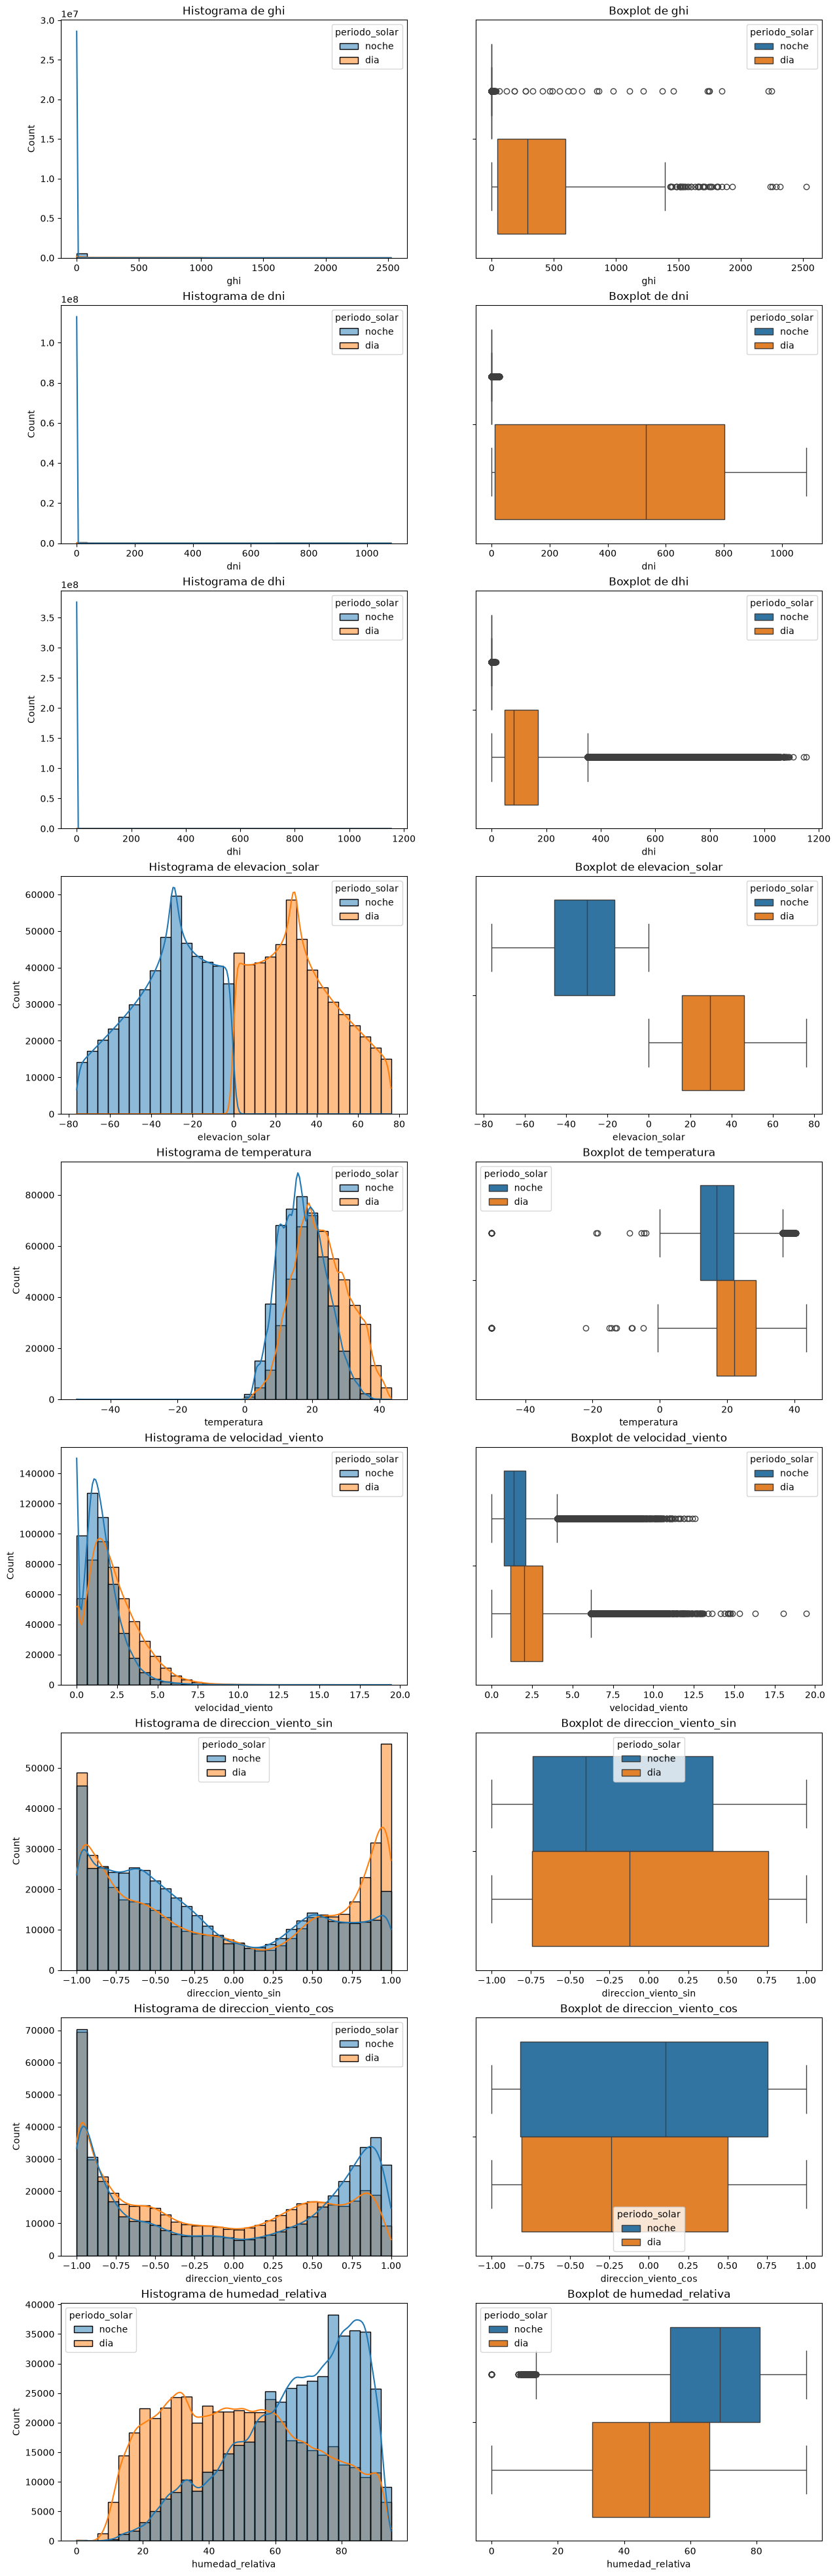

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_hist_box(df, numeric_columns):
    plt.figure(figsize=(15, 50))
    count = 1

    for col in numeric_columns:
        plt.subplot(len(numeric_columns), 2, count)
        sns.histplot(data=df, x=col, kde=True, hue='periodo_solar', bins=30)
        plt.title(f'Histograma de {col}')
        count += 1

        plt.subplot(len(numeric_columns), 2, count)
        sns.boxplot(data=df, x=col, hue='periodo_solar')
        plt.title(f'Boxplot de {col}')
        count += 1

plot_hist_box(df, numeric_columns)

## Comentarios sobre las variables

* **Irradiancias (`ghi`, `dni` y `dhi`)**: presentan una fuerte concentración de valores en cero, explicada principalmente por los registros nocturnos. Durante el día, las distribuciones se desplazan hacia valores positivos y muestran una elevada asimetría. La `dni` alcanza los valores centrales más altos durante el periodo diurno, mientras que `ghi` y `dhi` presentan colas derechas largas y numerosos valores extremos. Los máximos de `ghi` (2525,5 W/m²) y `dhi` (1153 W/m²) resultan especialmente elevados y deberían revisarse para comprobar si corresponden a errores, códigos de calidad o situaciones atmosféricas excepcionales. Además, `ghi` presenta valores altos para el periodo nocturno, cuando deberían ser 0 o cercanos a 0, como ocurre con `dni` y `dhi`.

* **Elevación solar**: separa claramente los periodos nocturnos y diurnos. Los valores negativos se asocian a la noche y los positivos al día, con un rango aproximado entre −76° y 76°. La mediana global es cercana a cero porque el conjunto incluye observaciones de ambos periodos. No se observan anomalías evidentes en su distribución.

* **Temperatura**: se concentra alrededor de valores templados, con una media de 19,95 °C y una mediana de 19,37 °C. Durante el día, las temperaturas son generalmente más altas que durante la noche. La distribución es relativamente equilibrada, aunque aparecen valores extremos, especialmente el mínimo de −50 °C, que probablemente corresponda a un error de medida o a un valor codificado.

* **Velocidad del viento**: muestra una distribución claramente asimétrica hacia la derecha. Predominan las velocidades bajas, con una mediana de 1,63 m/s, mientras que algunos registros alcanzan valores próximos a 19,44 m/s. Durante el día se observan, en general, velocidades algo mayores y una mayor dispersión que durante la noche. No existen registros negativos de velocidad.

* **Dirección del viento**: las componentes seno y coseno presentan distribuciones no uniformes, lo que indica la existencia de direcciones predominantes. También se aprecian diferencias entre el día y la noche. Al tratarse de una variable circular, estas componentes deben analizarse conjuntamente, preferiblemente mediante una rosa de los vientos o reconstruyendo el ángulo original.

* **Humedad relativa**: presenta una media del 57,31 % y una mediana del 59,08 %. Los valores son, en general, más altos durante la noche y más bajos durante el día, comportamiento coherente con la relación inversa habitual entre temperatura y humedad relativa. Los registros cercanos a cero son poco frecuentes y conviene revisarlos, ya que podrían corresponder a valores anómalos. No se tiene ningún registro negativo ni superior a 100.

Las distribuciones muestran diferencias claras entre el periodo diurno y nocturno. Antes del modelado conviene revisar los valores extremos de irradiancia y temperatura, estudiar los registros asociados a códigos de calidad y mantener la separación entre día y noche, ya que esta variable condiciona fuertemente el comportamiento de las irradiancias, la temperatura y la humedad relativa.


In [18]:
targets = ['codigo_ghi', 'codigo_dni', 'codigo_dhi']

for target in targets:
    print(target)
    resumen = (
        df.groupby(["ano", "periodo_solar"])[target]
        .value_counts(normalize=True)
        .mul(100)
        .rename("porcentaje")
        .reset_index()
    )
    display(resumen)

codigo_ghi


,ano,periodo_solar,codigo_ghi,porcentaje
0,2023,dia,0,80.226180
1,2023,dia,1,19.773820
2,2023,noche,0,96.117743
3,2023,noche,1,3.882257
4,2024,dia,0,81.400418
5,2024,dia,1,18.599582
6,2024,noche,0,84.483533
7,2024,noche,1,15.516467


codigo_dni


,ano,periodo_solar,codigo_dni,porcentaje
0,2023,dia,0,94.711316
1,2023,dia,1,4.881891
2,2023,dia,2,0.406793
3,2023,noche,0,97.005204
4,2023,noche,1,2.994796
5,2024,dia,0,82.477143
6,2024,dia,1,17.206968
7,2024,dia,2,0.315889
8,2024,noche,0,84.481997
9,2024,noche,1,15.517619


codigo_dhi


,ano,periodo_solar,codigo_dhi,porcentaje
0,2023,dia,0,81.402195
1,2023,dia,1,18.529380
2,2023,dia,2,0.068425
3,2023,noche,0,96.849590
4,2023,noche,1,3.150410
5,2024,dia,0,70.068918
6,2024,dia,1,29.853798
7,2024,dia,2,0.077284
8,2024,noche,0,78.806561
9,2024,noche,1,21.193439


## Comentarios sobre los códigos de las irradiancias

* **`codigo_ghi`**: el código `0` es mayoritario en todos los grupos, aunque su proporción disminuye durante el día. En 2023 representa el **80,23 %** de los registros diurnos y el **96,12 %** de los nocturnos. En 2024, el porcentaje nocturno de código `0` baja notablemente hasta el **84,48 %**, aumentando el código `1` hasta el **15,52 %**. Esto sugiere un empeoramiento de la calidad o un cambio en el criterio de codificación durante las noches de 2024.

* **`codigo_dni`**: en 2023 predominan claramente los registros con código `0`, tanto de día (**94,71 %**) como de noche (**97,01 %**). En 2024 aumenta de forma considerable la proporción del código `1`, especialmente durante el día, donde alcanza el **17,21 %**, frente al **4,88 %** de 2023. El código `2` es residual en ambos años, con porcentajes inferiores al **0,5 %**.

* **`codigo_dhi`**: presenta la mayor proporción de registros con código `1`. Durante el día pasa del **18,53 %** en 2023 al **29,85 %** en 2024. Por la noche también se observa un incremento importante, desde el **3,15 %** hasta el **21,19 %**. El código `2` tiene una presencia prácticamente testimonial.

Los códigos indican una reducción de la proporción de registros clasificados con código `0` en 2024, especialmente para `dhi` y en los periodos nocturnos. Esto podría deberse a una mayor presencia de observaciones problemáticas, a cambios en los sensores o a una modificación de los criterios de control de calidad.


In [19]:
df_2023 = df[df['ano'] == 2023].copy()
df_2024 = df[df['ano'] == 2024].copy()

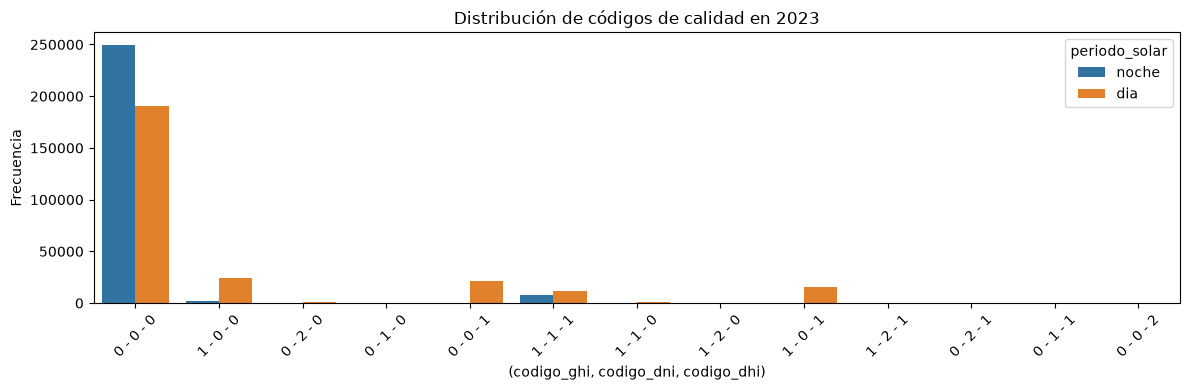

In [20]:
plt.figure(figsize=(12, 4))

sns.countplot(
    data=df_2023,
    x=df_2023[targets].astype(str).agg(' - '.join, axis=1),
    hue='periodo_solar'
)

plt.title('Distribución de códigos de calidad en 2023')
plt.xlabel('(codigo_ghi, codigo_dni, codigo_dhi)')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

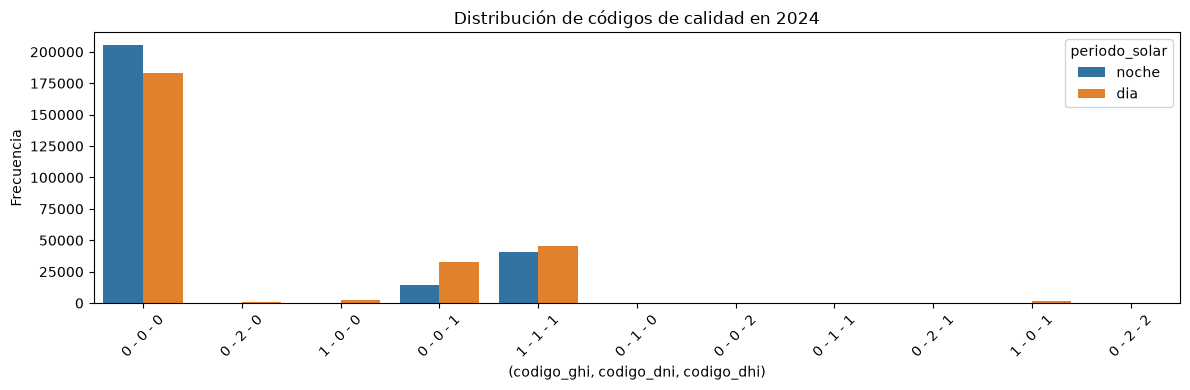

In [21]:
plt.figure(figsize=(12, 4))

sns.countplot(
    data=df_2024,
    x=df_2024[targets].astype(str).agg(' - '.join, axis=1),
    hue='periodo_solar'
)

plt.title('Distribución de códigos de calidad en 2024')
plt.xlabel('(codigo_ghi, codigo_dni, codigo_dhi)')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Códigos de calidad de las medidas

En ambos años, la combinación **(0, 0, 0)** es la más frecuente tanto durante el día como durante la noche, lo que indica que la mayoría de los registros de `ghi`, `dni` y `dhi` presentan simultáneamente el código de calidad 0.

En **2023**, los registros nocturnos se concentran casi por completo en la combinación **(0, 0, 0)**. Durante el día aparece una mayor diversidad de combinaciones, destacando **(1, 0, 0)**, **(0, 0, 1)** y **(1, 0, 1)**. Esto sugiere que las incidencias afectan principalmente a `ghi` y `dhi`, mientras que los problemas aislados o simultáneos en `dni` son menos frecuentes. La combinación **(1, 1, 1)** también aparece, aunque con una frecuencia claramente inferior a la de los registros completamente correctos.

En **2024** disminuye la diferencia entre el número de registros diurnos y nocturnos con combinación **(0, 0, 0)**. Además, aumentan notablemente las combinaciones **(0, 0, 1)** y, sobre todo, **(1, 1, 1)**, que presenta una frecuencia elevada tanto de día como de noche. Esto indica una mayor presencia de periodos en los que las tres irradiancias reciben simultáneamente el código 1.

Las combinaciones que contienen el código **2** siguen siendo muy poco frecuentes en ambos años, por lo que su influencia sobre el conjunto total es reducida. En general, los resultados muestran una mayor concentración de incidencias simultáneas en 2024, mientras que en 2023 predominan más los problemas aislados en `ghi` o `dhi`, especialmente durante el periodo diurno.


Ahora vamos a obtener la matriz de correlación entre features numéricas y los targets

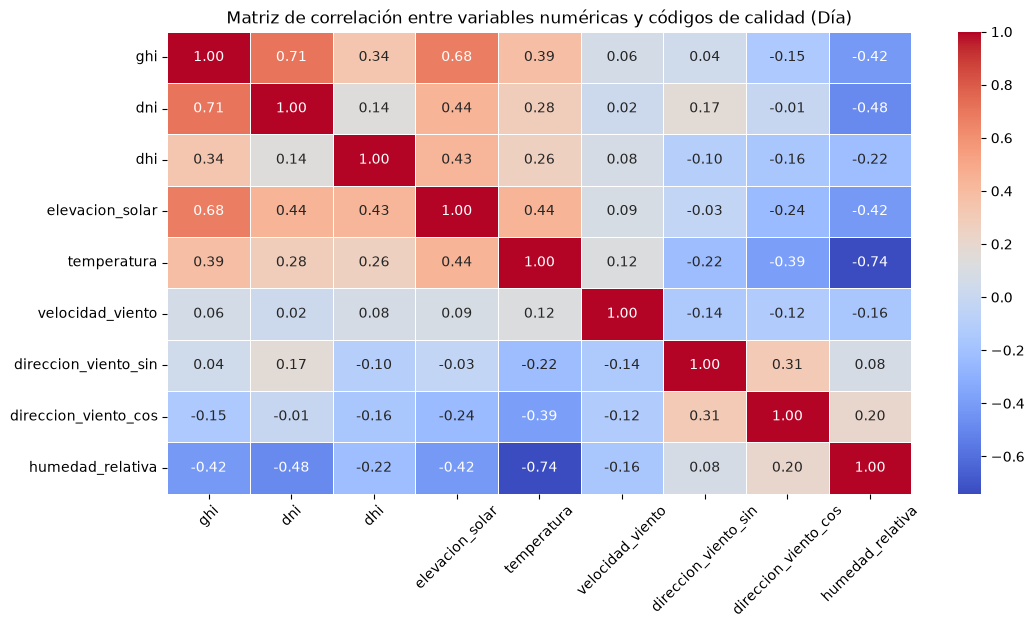

In [ ]:
corr = df[df['periodo_solar'] == 'dia'][numeric_columns].corr()
plt.figure(figsize=(12,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de correlación entre variables numéricas (Día)')
plt.xticks(rotation=45)
plt.show()

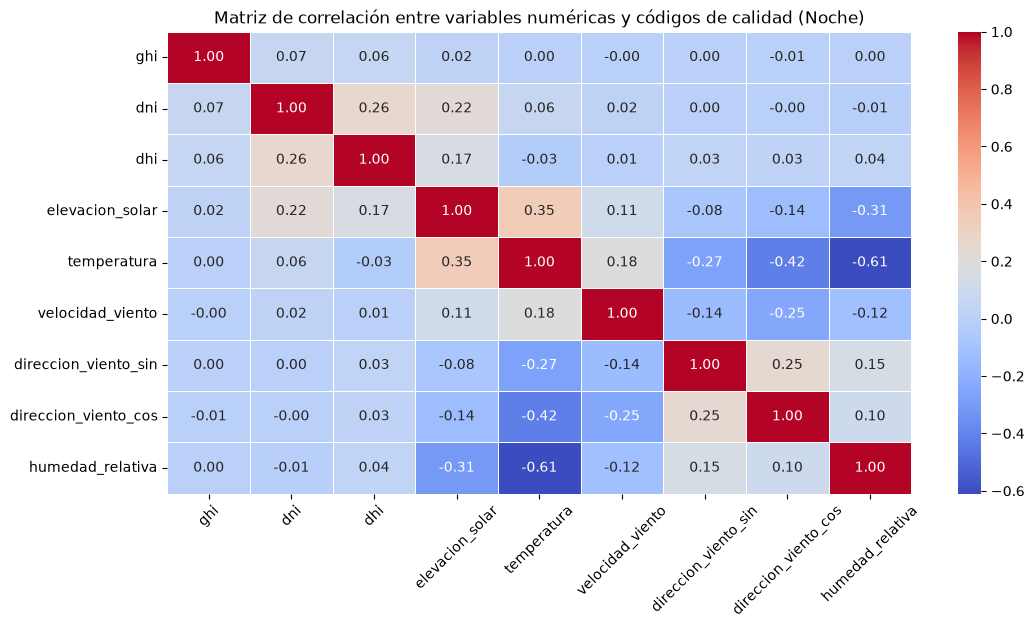

In [ ]:
corr = df[df['periodo_solar'] == 'noche'][numeric_columns].corr()
plt.figure(figsize=(12,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de correlación entre variables numéricas (Noche)')
plt.xticks(rotation=45)
plt.show()

## Correlación entre variables

Durante el **día**, las irradiancias presentan correlaciones positivas entre sí y con la elevación solar. Destacan `ghi`–`dni` (**0,71**) y `ghi`–`elevacion_solar` (**0,68**). La humedad relativa se relaciona negativamente con la temperatura (**−0,74**) y con las irradiancias.


In [ ]:
def features_per_time(df, columns, year=None):
    """
    Obtiene las medias de las columnas especificadas por mes y hora
    para un año específico y genera gráficos diferenciados por periodo solar.

    Parameters:
    - df: dataframe
    - year: año específico (None para todos)
    """

    if year is not None:
        df_year = df[df['ano'] == year].copy()
        title_suffix = f' - Año {year}'
    else:
        df_year = df.copy()
        title_suffix = ''

    df_year['mes'] = df_year['fecha'].dt.month
    df_year['hora'] = df_year['fecha'].dt.hour

    # Se añade periodo_solar al agrupamiento
    means_per_month = (
        df_year.groupby(['mes', 'periodo_solar'])[columns]
        .mean()
        .reset_index()
    )

    means_per_hour = (
        df_year.groupby(['hora', 'periodo_solar'])[columns]
        .mean()
        .reset_index()
    )

    count = 1
    print(f"Medias por mes y hora {title_suffix}:")

    plt.figure(figsize=(15, 40))

    for col in columns:

        plt.subplot(len(columns), 2, count)
        for periodo, data in means_per_month.groupby('periodo_solar'):
            plt.plot(data['mes'], data[col], label=periodo)
        plt.xlabel('Mes')
        plt.ylabel('Media')
        plt.title(f'{col} por Mes{title_suffix}')
        plt.legend(title='Periodo solar')
        count += 1

        plt.subplot(len(columns), 2, count)
        for periodo, data in means_per_hour.groupby('periodo_solar'):
            data = (
                data.set_index('hora')
                    .reindex(range(24))
            )

            plt.plot(data.index, data[col], label=periodo)

        plt.xlabel('Hora')
        plt.ylabel('Media')
        plt.title(f'{col} por Hora{title_suffix}')
        plt.legend(title='Periodo solar')
        count += 1

    plt.tight_layout()
    plt.show()

Medias por mes y hora  - Año 2023:


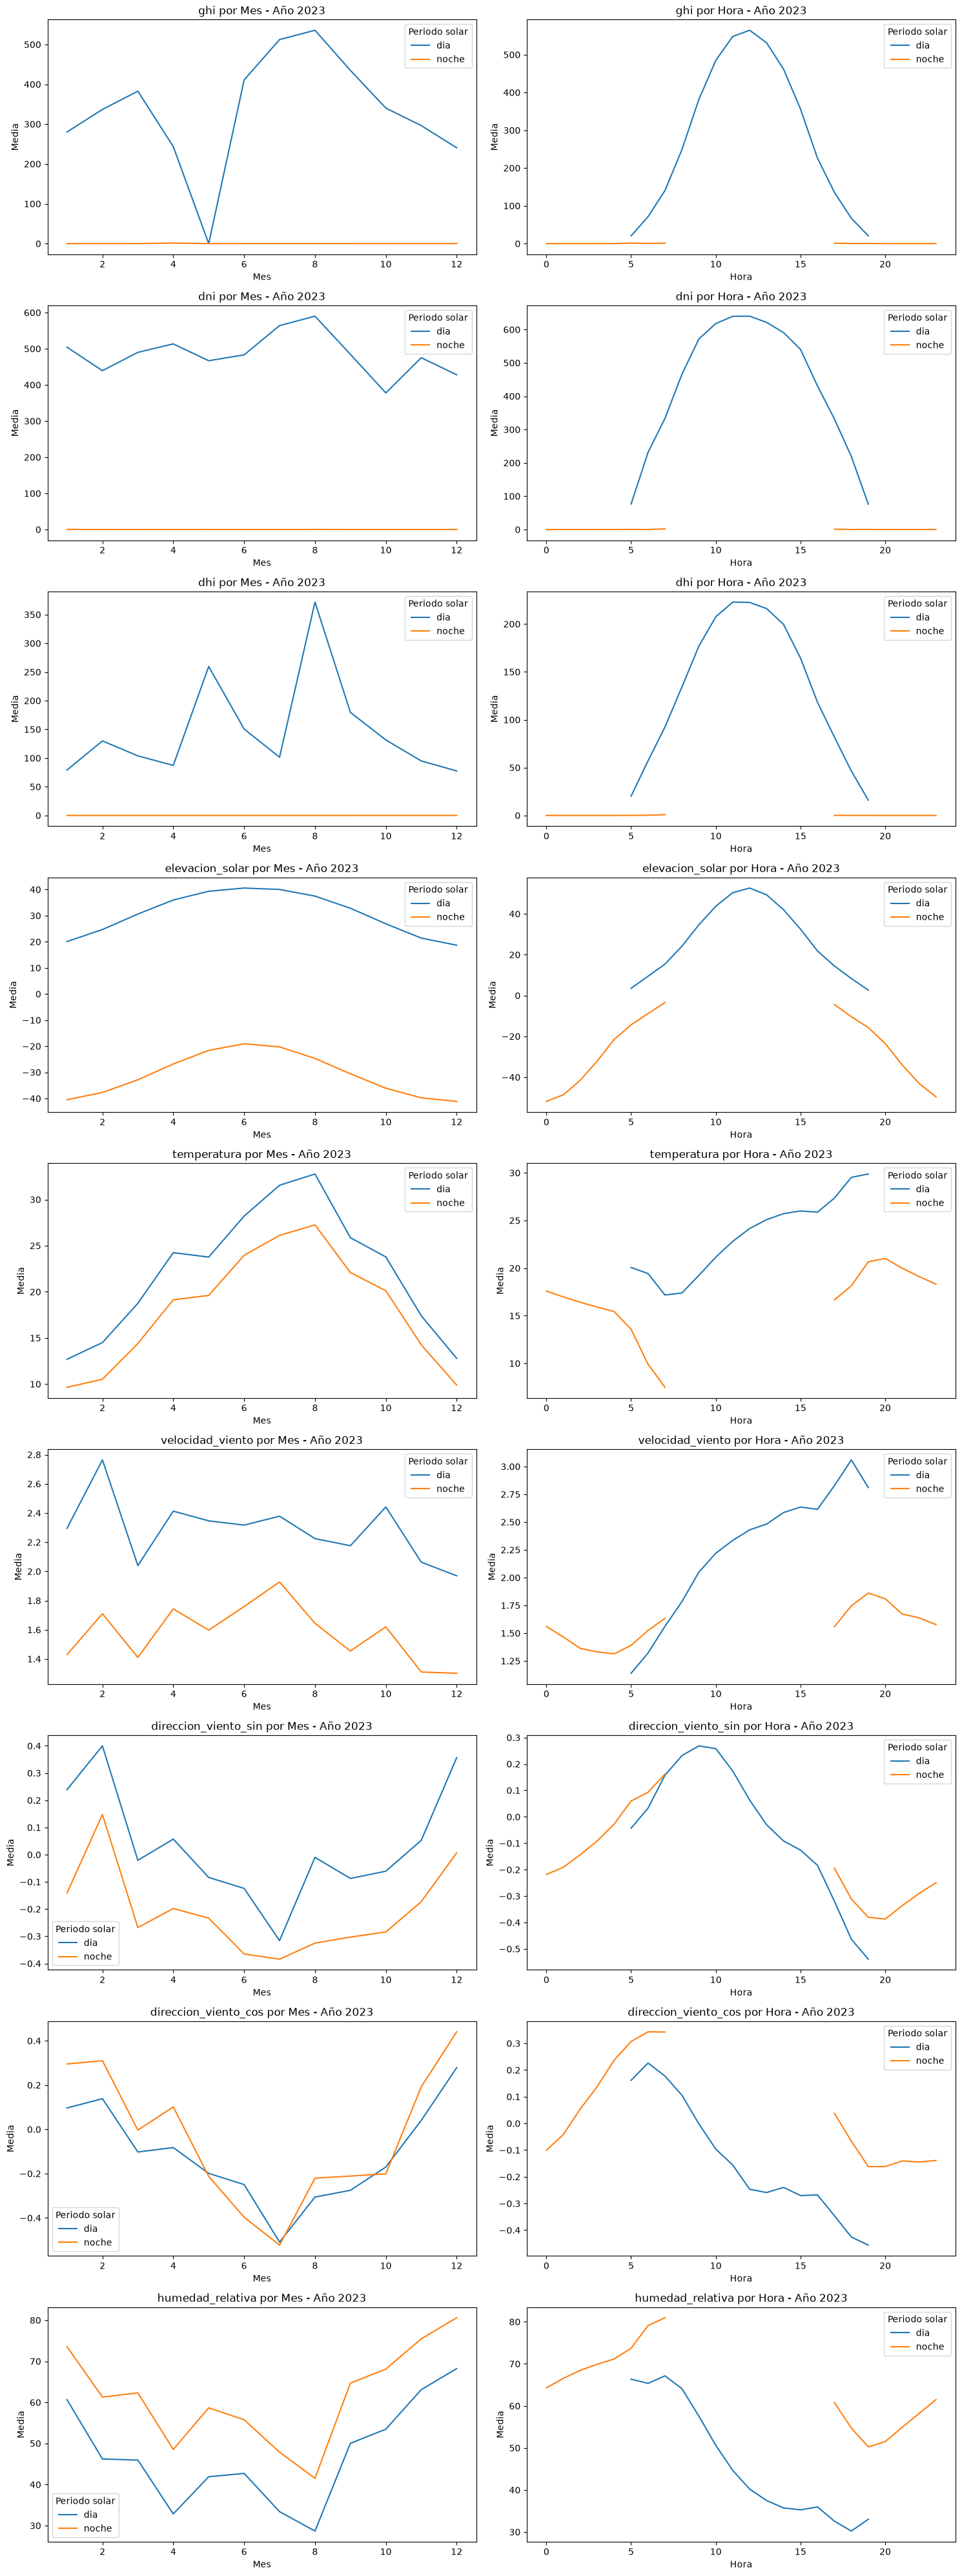

In [25]:
features_per_time(df, numeric_columns, 2023)

* `GHI`, `DNI` y `DHI` presentan durante el día un patrón horario similar al de la elevación solar: aumentan tras el amanecer, alcanzan sus máximos en las horas centrales y disminuyen al acercarse el atardecer.

* Durante la noche, las tres irradiancias permanecen prácticamente nulas. Por tanto, valores elevados con elevación solar negativa podrían indicar errores de medida o de clasificación.

* `DNI` muestra el perfil horario más marcado, mientras que `DHI` presenta una evolución más suave, al estar más influida por la nubosidad y la radiación difusa.

* La temperatura aumenta después del amanecer y alcanza su máximo más tarde que las irradiancias. La humedad relativa sigue, en general, un comportamiento inverso, con valores mayores durante la noche.

* La velocidad y la dirección del viento muestran patrones menos definidos y una mayor variabilidad, especialmente al analizar los datos por día del mes.

* La evolución mensual de las irradiancias sigue parcialmente la variación estacional de la elevación solar, aunque también está condicionada por las condiciones meteorológicas.

* La caída de `GHI` en mayo no coincide con la evolución de `DNI`, `DHI` ni de la elevación solar, por lo que conviene revisar ese periodo como posible anomalía de registro o preprocesamiento.

Las agrupaciones por mes y hora muestran patrones estacionales y diarios claros. En cambio, la agrupación por día del mes mezclaría observaciones de meses distintos, por lo que resulta menos representativa.


Medias por mes y hora  - Año 2024:


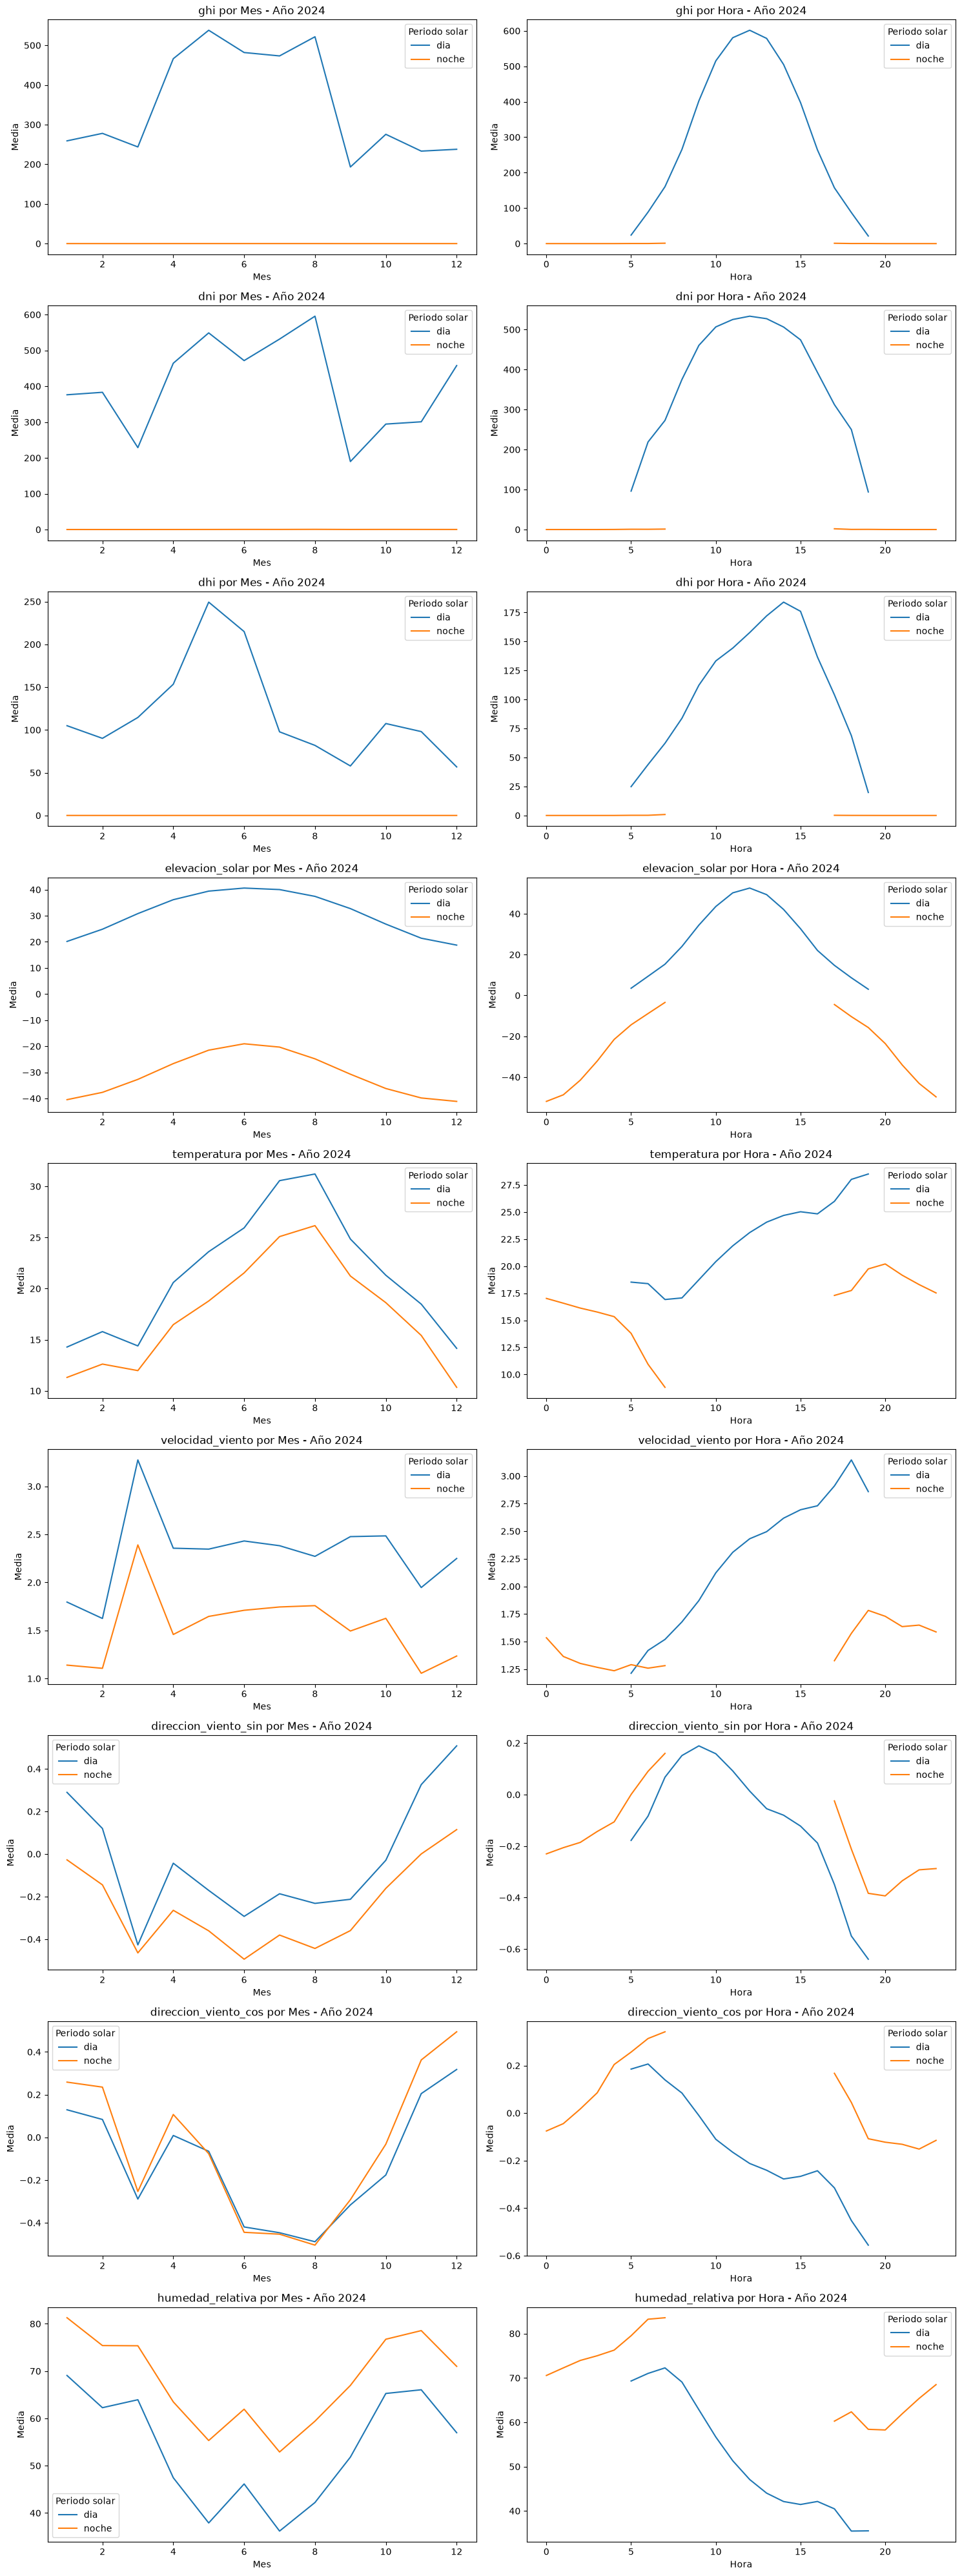

In [26]:
features_per_time(df, numeric_columns, 2024)

## Comparación mensual y por hora 2023–2024

* En ambos años, `GHI`, `DNI` y `DHI` siguen un patrón horario coherente con la elevación solar: valores prácticamente nulos durante la noche, aumento tras el amanecer y máximos en las horas centrales.

* Los perfiles horarios son similares entre años, lo que confirma la relevancia de la hora y de la elevación solar para detectar posibles anomalías en las irradiancias.

* En 2023 destaca una caída anómala de `GHI` en mayo, que no coincide con la evolución de la elevación solar ni con el resto de irradiancias. Esta anomalía no aparece en 2024.

* En 2024 se observa una disminución brusca de `GHI`, `DNI` y `DHI` en septiembre. Al afectar simultáneamente a las tres variables, conviene revisar la disponibilidad y calidad de los registros de ese mes.

* La `DNI` y la `DHI` alcanzan valores horarios mayores en 2023, mientras que la `GHI` presenta un máximo algo superior en 2024.

* La temperatura y la humedad relativa mantienen comportamientos inversos en ambos años. En 2024 se observan, en general, valores de humedad más elevados.

* La velocidad y la dirección del viento muestran mayor variabilidad y patrones menos estables, aunque la velocidad del viento tiende a ser ligeramente superior durante el día en 2024.

In [27]:
features = [
    "ghi",
    "dni",
    "dhi",
]

df_dia = df[df["elevacion_solar"] > 0].copy()

df_dia_2023 = df_dia[df_dia["ano"] == 2023].copy()
df_dia_2024 = df_dia[df_dia["ano"] == 2024].copy()

In [28]:
comparison = pd.DataFrame({
    "media_2023": df_dia_2023[features].mean(),
    "media_2024": df_dia_2024[features].mean(),
    "mediana_2023": df_dia_2023[features].median(),
    "mediana_2024": df_dia_2024[features].median(),
    "std_2023": df_dia_2023[features].std(),
    "std_2024": df_dia_2024[features].std()
})

comparison["cambio_media_pct"] = (
    (comparison["media_2024"] - comparison["media_2023"])
    / comparison["media_2023"].abs()
    * 100
)

comparison


,media_2023,media_2024,mediana_2023,mediana_2024,std_2023,std_2024,cambio_media_pct
ghi,338.586217,368.837006,272.583,305.2500,310.927161,320.142892,8.934442
dni,489.278634,417.892254,591.917,448.5695,353.377330,362.253938,-14.590128
dhi,153.973427,124.002099,89.000,71.8330,172.936125,152.790303,-19.465260


## Comparación estadística entre 2023 y 2024 durante el periodo diurno

* **GHI**: aumenta de **338,59** a **368,84 W/m²** (+8,93 %), con una variabilidad ligeramente mayor en 2024.

* **DNI**: disminuye de **489,28** a **417,89 W/m²** (−14,59 %) y presenta una mayor dispersión en 2024.

* **DHI**: disminuye de **153,97** a **124,00 W/m²** (−19,47 %) y presenta una menor variabilidad en 2024.

Estas medias marginales describen diferencias interanuales, pero no permiten comprobar directamente la ecuación física de cierre ni atribuir los cambios a una causa meteorológica concreta. La contribución directa a `GHI` depende del producto $\mathrm{DNI}\sin(\alpha)$ en cada instante, por lo que también intervienen la distribución de la elevación solar, la disponibilidad de los registros y la coincidencia temporal entre las tres componentes.

Por tanto, los resultados muestran un cambio en la distribución de las irradiancias entre ambos años, pero no permiten concluir por sí solos que 2024 fuera más nuboso ni que exista una incoherencia física entre sus valores medios.

In [ ]:
def analyze_missing_values(df, columns, year=None):
    """
    Analiza los valores ausentes en las columnas especificadas.
    
    Parameters:
    - df: dataframe
    - year: año específico (None para todos)
    """
    df_filtered = df[df['ano'] == year].copy() if year is not None else df.copy()
    title_suffix = f' - Año {year}' if year is not None else ''

    missing_count = df_filtered.groupby('periodo_solar')[columns].apply(lambda x: x.isnull().sum())
    missing_pct = df_filtered.groupby('periodo_solar')[columns].apply(lambda x: x.isnull().mean() * 100)

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    sns.barplot(data=missing_count.T.reset_index().melt('index', var_name='periodo_solar', value_name='Nulos'),
                x='Nulos', y='index', hue='periodo_solar', ax=axes[0, 0])
    axes[0, 0].set(title=f'Cantidad de nulos{title_suffix}', xlabel='Número de nulos', ylabel='Variable')

    sns.barplot(data=missing_pct.T.reset_index().melt('index', var_name='periodo_solar', value_name='Porcentaje'),
                x='Porcentaje', y='index', hue='periodo_solar', ax=axes[0, 1])
    axes[0, 1].set(title=f'Porcentaje de nulos{title_suffix}', xlabel='Porcentaje (%)', ylabel='Variable')

    for ax, periodo in zip(axes[1], ['dia', 'noche']):
        null_corr = df_filtered.loc[df_filtered['periodo_solar'] == periodo, columns].isnull().astype(int).corr()
        sns.heatmap(null_corr, annot=True, cmap='RdYlGn_r', fmt='.2f', vmin=-1, vmax=1, ax=ax)
        ax.set_title(f'Correlación de nulos - {periodo}{title_suffix}')
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

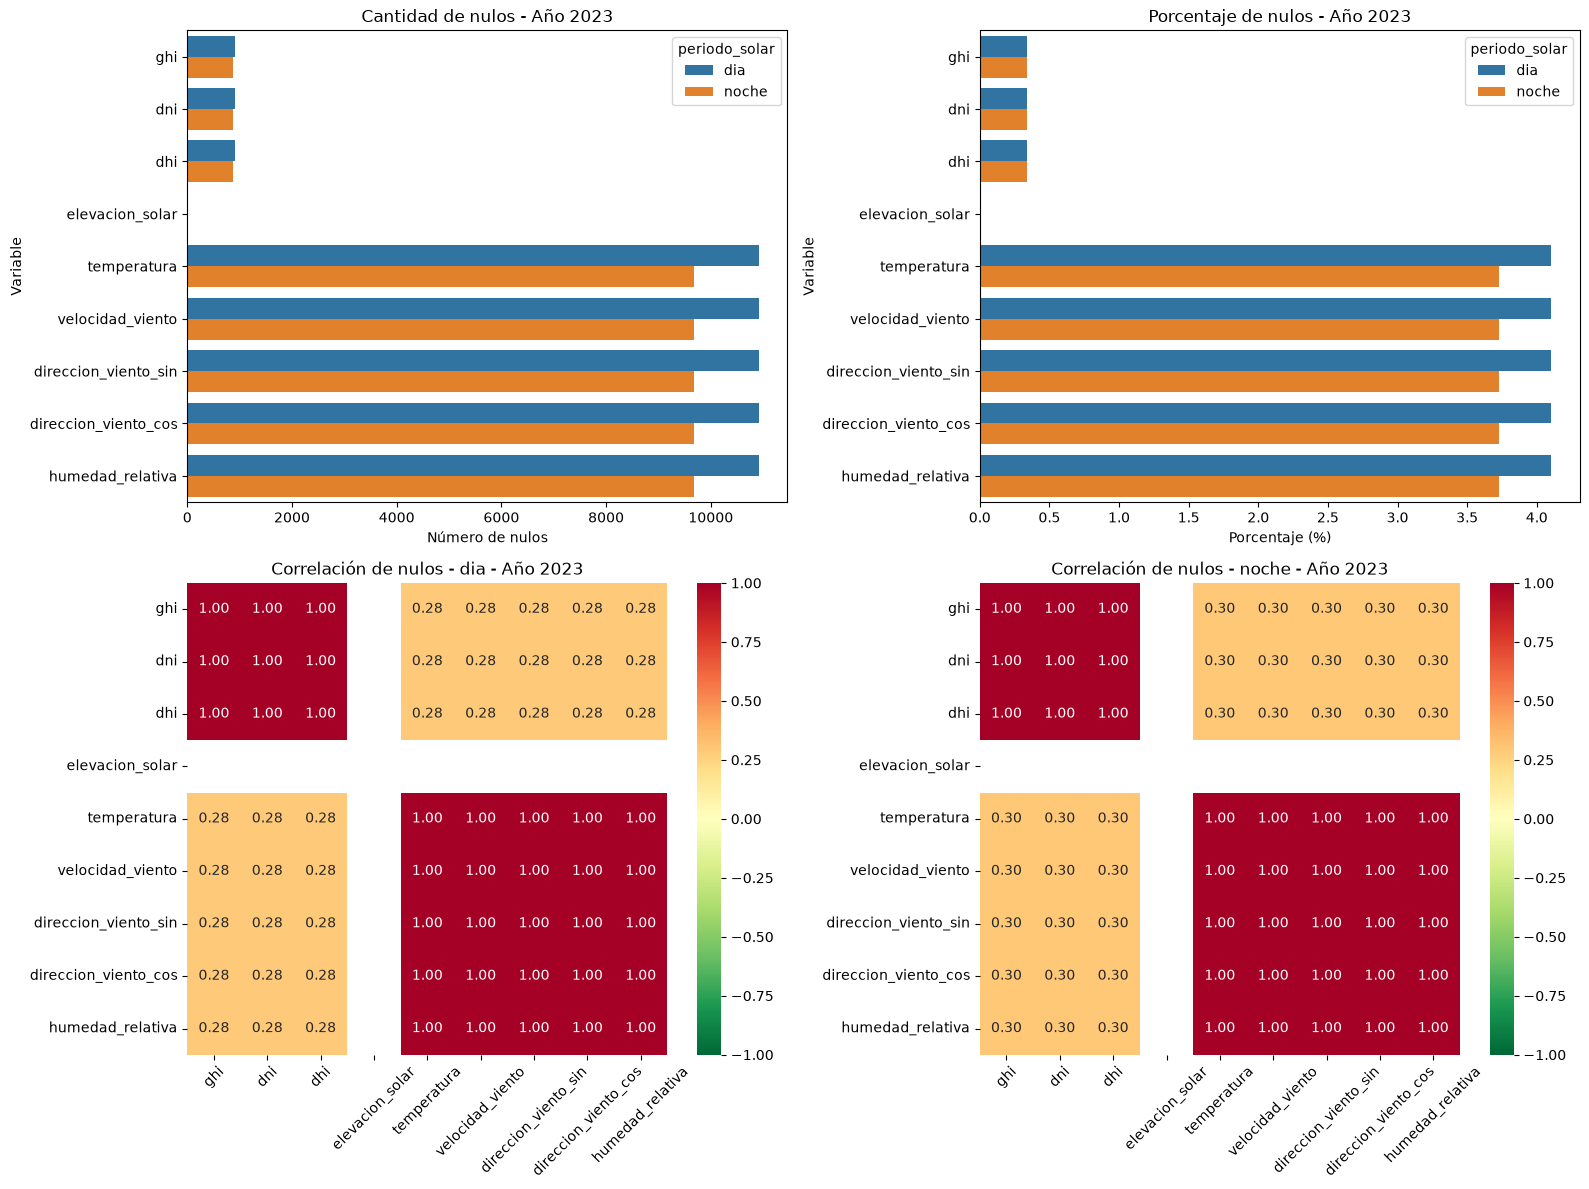

In [30]:
analyze_missing_values(df, numeric_columns, 2023)

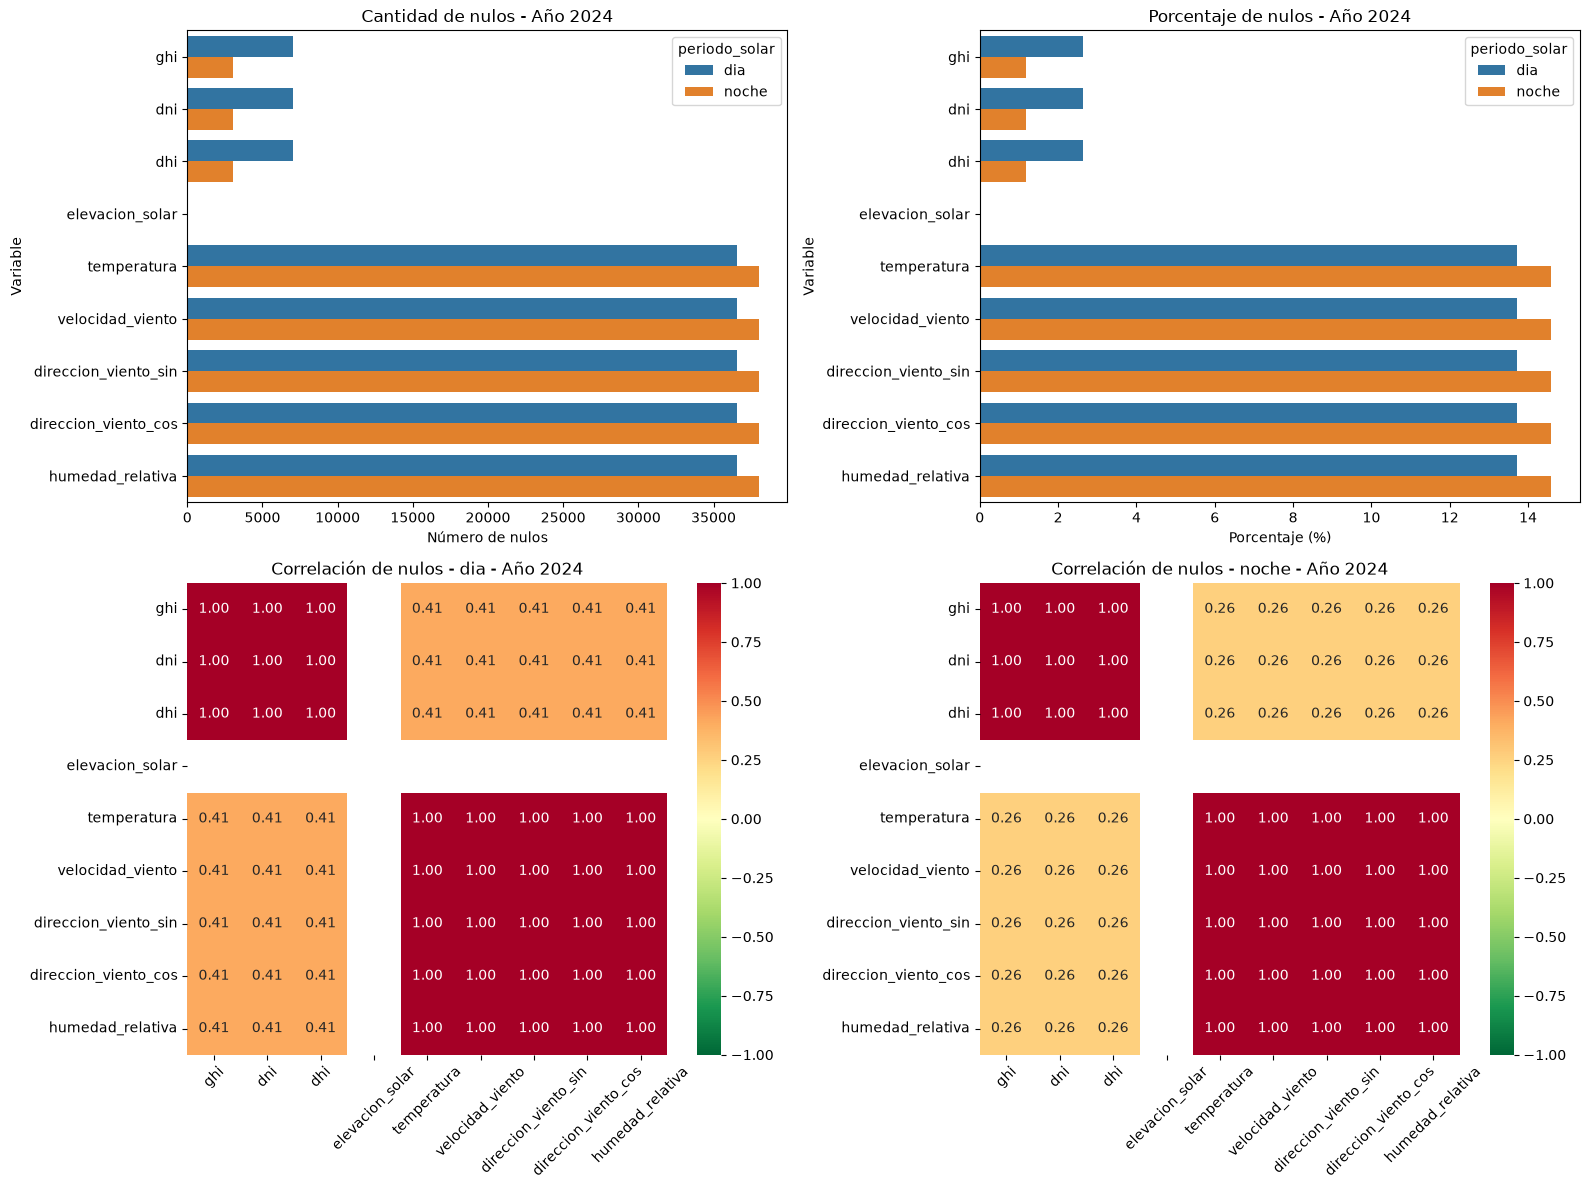

In [31]:
analyze_missing_values(df, numeric_columns, 2024)

* En **2023**, las variables meteorológicas `temperatura`, `velocidad_viento`, `direccion_viento_sin`, `direccion_viento_cos` y `humedad_relativa` presentan alrededor de un **4 % de valores nulos**, con una proporción ligeramente mayor durante el día.

* En **2024**, el porcentaje de valores ausentes aumenta de forma notable, alcanzando aproximadamente el **14–15 %** en esas mismas variables. En este caso, la proporción es ligeramente superior durante la noche.

* `GHI`, `DNI` y `DHI` presentan pocos valores nulos en ambos años, aunque en **2024** su porcentaje aumenta respecto a 2023, especialmente durante el periodo diurno.

* La `elevacion_solar` no presenta valores ausentes, por lo que puede utilizarse como variable de referencia temporal y para distinguir entre día y noche.

* Los mapas de correlación muestran que los nulos de `GHI`, `DNI` y `DHI` aparecen simultáneamente, con correlaciones de **1,00**. Lo mismo ocurre entre las variables meteorológicas, lo que indica que sus valores ausentes se producen en los mismos registros.

* La relación entre los nulos de las irradiancias y los de las variables meteorológicas es moderada: alrededor de **0,28–0,30** en 2023, **0,41** durante el día de 2024 y **0,26** durante la noche.

Por lo tanto, **2024 presenta un problema de datos ausentes mucho más relevante que 2023**, por lo que conviene identificar los periodos temporales afectados antes de aplicar técnicas de imputación o eliminar registros.


In [ ]:
def analyze_missing_temporal_patterns(df, year=None):
    """
    Analiza los patrones temporales de valores ausentes.
    Muestra nulos por mes y por hora del día.
    
    Parameters:
    - df: dataframe
    - year: año específico (None para todos)
    """

    df_filtered = df[df['ano'] == year].copy() if year is not None else df.copy()
    title_suffix = f' - Año {year}' if year is not None else ''

    df_filtered['mes'] = df_filtered['fecha'].dt.month
    df_filtered['hora'] = df_filtered['fecha'].dt.hour

    # Una variable representativa de cada grupo
    groups = {'Irradiancias': 'ghi', 'Meteorológicas': 'temperatura'}

    fig, axes = plt.subplots(2, 2, figsize=(16, 8))

    for ax, temporal, percentage in zip(axes.flat, ['mes', 'mes', 'hora', 'hora'], [False, True, False, True]):
        for group, col in groups.items():
            missing = df_filtered.groupby([temporal, 'periodo_solar'])[col].apply(
                lambda x: x.isnull().mean() * 100 if percentage else x.isnull().sum()
            ).reset_index(name='nulos')

            for periodo, data in missing.groupby('periodo_solar'):
                ax.plot(data[temporal], data['nulos'], marker='o', label=f'{group} - {periodo}')

        tipo = 'Porcentaje de nulos' if percentage else 'Valores nulos'
        ax.set_title(f'{tipo} por {temporal}{title_suffix}')
        ax.set_xlabel(temporal.capitalize())
        ax.set_ylabel('Porcentaje (%)' if percentage else 'Cantidad de nulos')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()
    


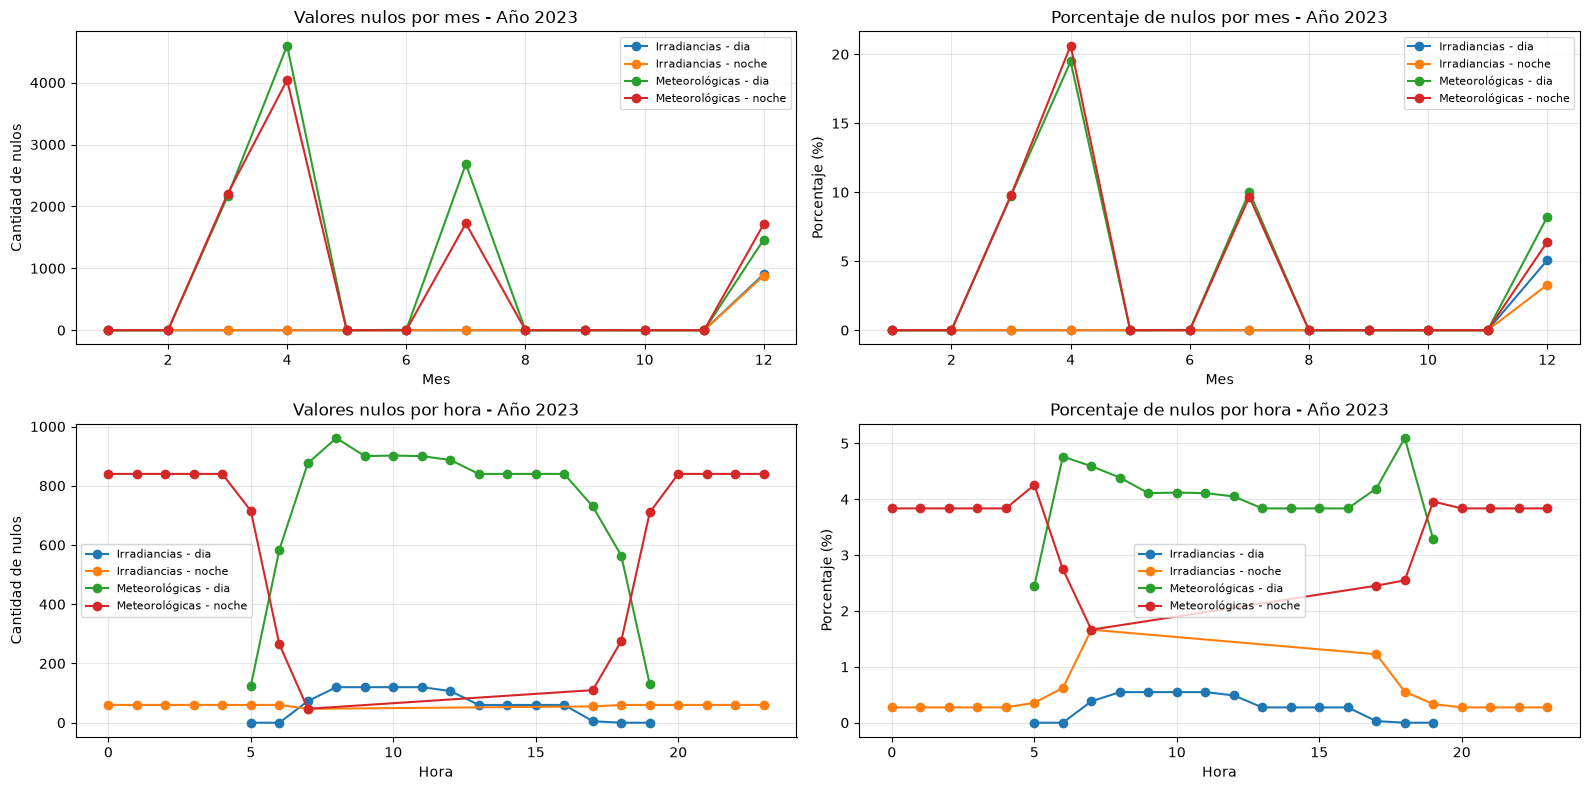

In [33]:
analyze_missing_temporal_patterns(df, year=2023)

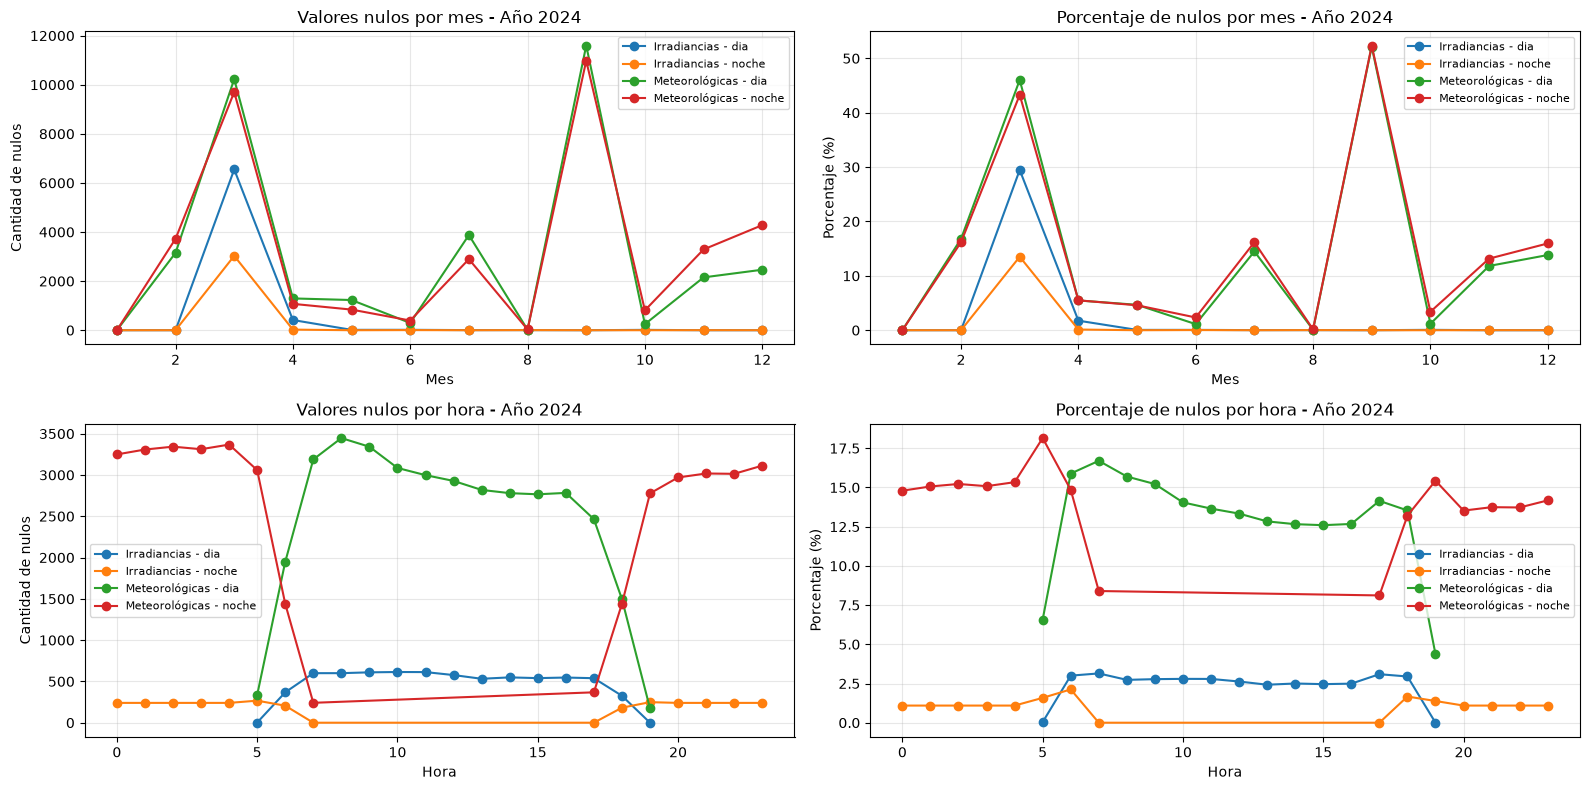

In [34]:
analyze_missing_temporal_patterns(df, year=2024)

## Patrones temporales de valores nulos en 2023 y 2024

* En **2023**, los valores ausentes se concentran principalmente en **marzo, abril, julio y diciembre**. El máximo aparece en abril, con cerca del **20 %** de nulos en las variables meteorológicas.

* En **2024**, la ausencia de datos es mucho más elevada y se distribuye en más meses. Destacan especialmente **marzo** y **septiembre**, con aproximadamente un **45 %** y un **52 %** de nulos meteorológicos, respectivamente.

* Las irradiancias presentan menos valores ausentes que las variables meteorológicas en ambos años. No obstante, en marzo de 2024 alcanzan valores relevantes, especialmente durante el día, con cerca del **30 %** de registros nulos.

* En 2024 también aparecen incrementos moderados de nulos en febrero, julio, noviembre y diciembre. En cambio, enero y agosto apenas presentan datos ausentes.

* Por hora, los nulos meteorológicos aparecen tanto de día como de noche. En 2023 se sitúan generalmente alrededor del **4–5 %**, mientras que en 2024 aumentan hasta valores próximos al **13–17 %**.

* Los nulos de irradiancia se concentran principalmente en las horas diurnas, aunque existe una pequeña proporción durante la noche. En 2024 su porcentaje horario es superior al de 2023.

* Los saltos entre los tramos diurnos y nocturnos se deben al cambio estacional de las horas de salida y puesta del sol, ya que una misma hora puede pertenecer al día o a la noche según el mes.

* De esta manera, **2024 presenta un problema de valores ausentes mucho más severo que 2023**, especialmente en las variables meteorológicas y en los meses de marzo y septiembre.


Se van a representar conjuntamente las tres componentes de irradiancia para estudiar sus relaciones y comprobar su coherencia con la ecuación de cierre:

$$
\boxed{
\mathrm{GHI}
=
\mathrm{DHI}
+
\mathrm{DNI}\max\left(\sin(\alpha),0\right)
}
$$

donde:

* $\mathrm{GHI}$: irradiancia global horizontal $[\mathrm{W/m^2}]$.
* $\mathrm{DNI}$: irradiancia directa normal $[\mathrm{W/m^2}]$.
* $\mathrm{DHI}$: irradiancia difusa horizontal $[\mathrm{W/m^2}]$.
* $\alpha$: ángulo de elevación solar.

Durante el periodo diurno, la componente horizontal de la irradiancia directa se calcula como $\mathrm{DNI}\sin(\alpha)$. Cuando el Sol se encuentra bajo el horizonte, esta contribución se fija en cero para evitar una componente directa horizontal negativa sin significado físico.

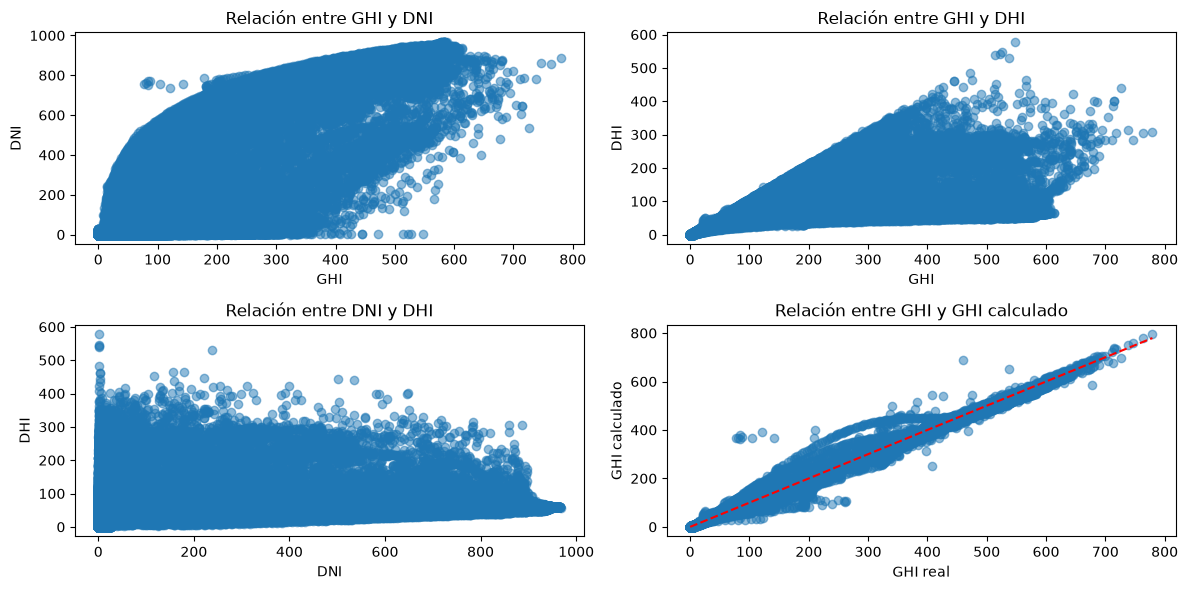

In [ ]:
import numpy as np

# Para evitar una contribución horizontal negativa del DNI cuando el Sol
# está bajo el horizonte, se limita el seno de la elevación a valores no negativos.
sin_elevacion = np.sin(
    np.radians(df["elevacion_solar"])
).clip(lower=0)

df['ghi_estimado'] = (
    df['dhi']
    + df['dni'] * sin_elevacion
)

eneros = df[df['fecha'].dt.month == 1].copy()

plt.figure(figsize=(12, 6))
plt.subplot(2,2,1)
plt.scatter(eneros['ghi'], eneros['dni'], alpha=0.5)
plt.xlabel('GHI')
plt.ylabel('DNI')
plt.title('Relación entre GHI y DNI')

plt.subplot(2,2,2)
plt.scatter(eneros['ghi'], eneros['dhi'], alpha=0.5)
plt.xlabel('GHI')
plt.ylabel('DHI')
plt.title('Relación entre GHI y DHI')

plt.subplot(2,2,3)
plt.scatter(eneros['dni'], eneros['dhi'], alpha=0.5)
plt.xlabel('DNI')
plt.ylabel('DHI')
plt.title('Relación entre DNI y DHI')

plt.subplot(2,2,4)
plt.scatter(eneros['ghi'], eneros['ghi_estimado'], alpha=0.5)
plt.plot([eneros['ghi'].min(), eneros['ghi'].max()], [eneros['ghi'].min(), eneros['ghi'].max()], linestyle='--', color='red')
plt.xlabel('GHI real')
plt.ylabel('GHI calculado')
plt.title('Relación entre GHI y GHI calculado')

plt.tight_layout()
plt.show()

Los gráficos corresponden a los registros de **enero de 2023 y enero de 2024 considerados conjuntamente**.

Las relaciones de `GHI` con `DNI` y `DHI` no son lineales, ya que la contribución de la radiación directa a una superficie horizontal depende del ángulo de elevación solar. Además, `DNI` y `DHI` representan componentes diferentes de la radiación y pueden evolucionar de forma distinta según las condiciones atmosféricas.

La comparación entre la `GHI` medida y la reconstruida mediante la ecuación de cierre muestra una tendencia general próxima a la recta de identidad. No obstante, también aparecen observaciones alejadas de dicha recta, lo que indica que la igualdad no se cumple con la misma precisión en todos los registros.

Estas desviaciones no deben atribuirse directamente a la nubosidad, ya que su efecto debería estar reflejado en las tres componentes medidas. Las diferencias pueden estar relacionadas con errores de medición, problemas de calibración, sombreado, diferencias en los tiempos de adquisición o promediado y desajustes temporales entre los sensores.

In [36]:
df["error_balance"] = df["ghi"] - df["ghi_estimado"]
df["error_balance_abs"] = df["error_balance"].abs()

df["error_balance_rel"] = (
    df["error_balance_abs"]
    / df["ghi"].abs().clip(lower=10)
)

In [37]:
error_stats = df[
    ["error_balance", "error_balance_abs", "error_balance_rel"]
].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).T

error_stats

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
error_balance,1040772.0,-27.565974,156.579686,-1546.447212,-874.059987,-229.147127,0.0,0.0,2.834000,41.856450,100.232248,2512.275228
error_balance_abs,1040772.0,42.780629,153.123798,0.000000,0.000000,0.000000,0.0,0.0,12.934420,243.734937,875.983059,2512.275228
error_balance_rel,1040772.0,2.191976,13.281933,0.000000,0.000000,0.000000,0.0,0.0,0.044374,0.794099,87.398198,154.644721


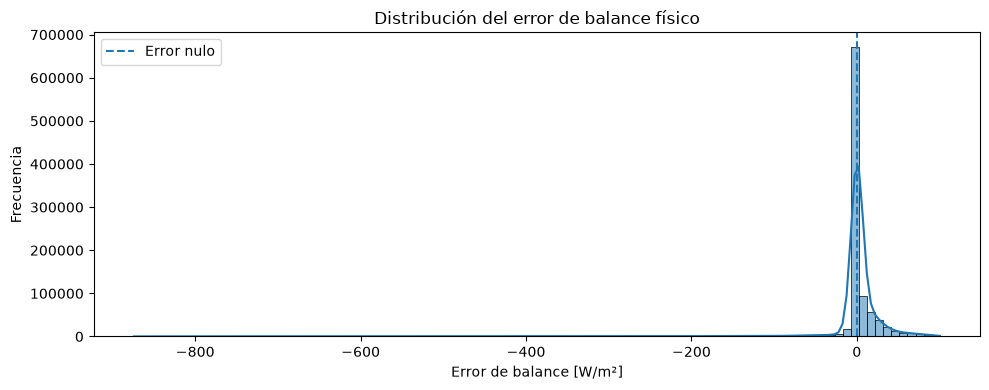

In [38]:
error_plot = df["error_balance"].dropna()

lim_inf = error_plot.quantile(0.01)
lim_sup = error_plot.quantile(0.99)

plt.figure(figsize=(10, 4))

sns.histplot(
    error_plot[
        error_plot.between(lim_inf, lim_sup)
    ],
    bins=100,
    kde=True
)

plt.axvline(0, linestyle="--", label="Error nulo")
plt.xlabel("Error de balance [W/m²]")
plt.ylabel("Frecuencia")
plt.title("Distribución del error de balance físico")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
umbrales = [10, 25, 50, 100, 200]

errores_validos = df["error_balance_abs"].dropna()

resumen_umbrales = pd.DataFrame({
    "umbral_w_m2": umbrales,
    "n_registros": [
        (errores_validos > umbral).sum()
        for umbral in umbrales
    ],
    "porcentaje": [
        (errores_validos > umbral).mean() * 100
        for umbral in umbrales
    ]
})

resumen_umbrales

,umbral_w_m2,n_registros,porcentaje
0,10,284574,27.034314
1,25,184637,17.540375
2,50,118159,11.225015
3,100,76575,7.274567
4,200,57255,5.439181


## Distribución del error de balance físico

* El error de balance presenta una concentración muy elevada en **0 W/m²**, con una mediana nula. Al tratarse el error absoluto de una variable no negativa, esta mediana indica que al menos la mitad de los registros presenta un error igual a cero. Esta concentración se debe principalmente a las observaciones nocturnas, en las que las irradiancias son generalmente nulas.

* El error firmado medio es de **−27,57 W/m²**, lo que indica que, en promedio, la `GHI` reconstruida es superior a la `GHI` medida. La diferencia entre la media negativa y la mediana nula muestra que el resultado está condicionado por una cola de errores negativos de gran magnitud.

* El **75 %** de los registros presenta un error absoluto inferior o igual a **12,93 W/m²**. Sin embargo, el percentil 95 aumenta hasta **243,73 W/m²** y el percentil 99 hasta **875,98 W/m²**, mostrando una distribución fuertemente asimétrica y con una cola de valores extremos.

* Considerando únicamente los registros para los que puede calcularse el balance, un **27,34 %** supera un error absoluto de **10 W/m²**, un **17,74 %** supera los **25 W/m²**, un **11,35 %** supera los **50 W/m²**, un **7,36 %** supera los **100 W/m²** y un **5,50 %** supera los **200 W/m²**.

En el conjunto global, la ecuación de cierre presenta desviaciones reducidas en la mayoría de los registros, pero existe un subconjunto relevante con inconsistencias elevadas. No obstante, esta distribución está fuertemente condicionada por la elevada proporción de registros nocturnos, por lo que los resultados diurnos y nocturnos deben analizarse separadamente.

In [40]:
resumen_por_codigo = {}

for target in targets:
    resumen = (
        df.groupby(target)["error_balance_abs"]
        .agg(
            cantidad="count",
            media="mean",
            mediana="median",
            desviacion="std",
            percentil_90=lambda x: x.quantile(0.90),
            percentil_95=lambda x: x.quantile(0.95),
            percentil_99=lambda x: x.quantile(0.99)
        )
    )

    resumen_por_codigo[target] = resumen

    print(f"\nError absoluto según {target}")
    display(resumen)


Error absoluto según codigo_ghi


,cantidad,media,mediana,desviacion,percentil_90,percentil_95,percentil_99
codigo_ghi,,,,,,,
0,899892,23.516097,0.0,85.069324,41.280868,87.105270,552.050907
1,140880,165.835700,0.0,330.875945,756.033054,948.876502,1328.723413



Error absoluto según codigo_dni


,cantidad,media,mediana,desviacion,percentil_90,percentil_95,percentil_99
codigo_dni,,,,,,,
0,943590,46.329848,0.379790,159.405218,66.932569,289.567895,899.208120
1,95257,8.362308,0.000000,56.004913,2.743458,32.679592,184.599168
2,1925,6.198079,3.106382,8.862546,18.204011,25.896940,41.694034



Error absoluto según codigo_dhi


,cantidad,media,mediana,desviacion,percentil_90,percentil_95,percentil_99
codigo_dhi,,,,,,,
0,859937,23.904621,0.000000,102.028014,36.721996,74.006759,700.150350
1,180447,132.743060,0.000000,275.374090,530.801337,721.223808,1305.089373
2,388,39.499510,15.660998,50.261266,120.492539,153.552472,215.249372


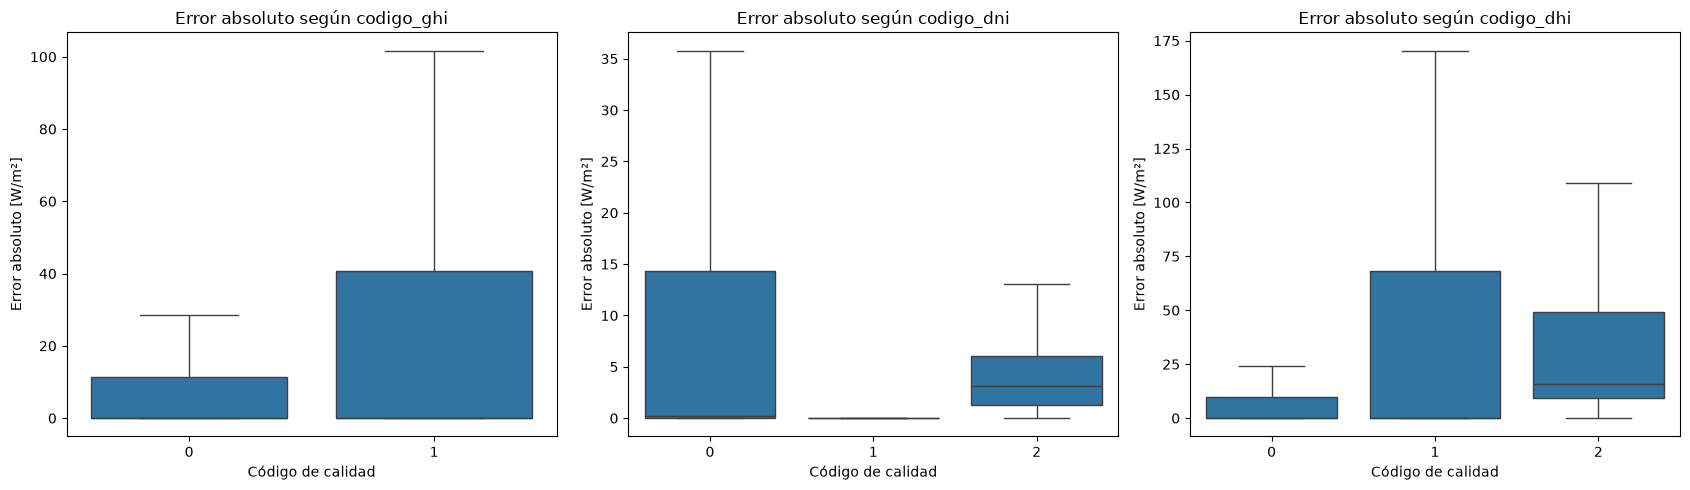

In [41]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(17, 5)
)

for ax, target in zip(axes, targets):
    data_plot = df[
        [target, "error_balance_abs"]
    ].dropna()

    limite = data_plot["error_balance_abs"].quantile(0.99)

    sns.boxplot(
        data=data_plot[
            data_plot["error_balance_abs"] <= limite
        ],
        x=target,
        y="error_balance_abs",
        ax=ax,
        showfliers=False
    )

    ax.set_title(f"Error absoluto según {target}")
    ax.set_xlabel("Código de calidad")
    ax.set_ylabel("Error absoluto [W/m²]")

plt.tight_layout()
plt.show()

In [55]:
for target in targets:
    resumen_signo = (
        df.groupby(target)["error_balance"]
        .agg(
            media="mean",
            mediana="median",
            porcentaje_positivo=lambda x: (
                x.dropna().gt(0).mean() * 100
            ),
            porcentaje_negativo=lambda x: (
                x.dropna().lt(0).mean() * 100
            ))
    )

    print(f"\nSigno del error según {target}")
    display(resumen_signo)


Signo del error según codigo_ghi


,media,mediana,porcentaje_positivo,porcentaje_negativo
codigo_ghi,,,,
0,-7.186240,0.0,35.051762,14.580750
1,-157.744562,0.0,6.523992,32.886854



Signo del error según codigo_dni


,media,mediana,porcentaje_positivo,porcentaje_negativo
codigo_dni,,,,
0,-30.515793,0.000000,33.382401,18.389555
1,1.148074,0.000000,8.973619,3.330989
2,-2.524131,0.510027,56.000000,44.000000



Signo del error según codigo_dhi


,media,mediana,porcentaje_positivo,porcentaje_negativo
codigo_dhi,,,,
0,-7.282649,0.000000,34.993377,13.729610
1,-124.203676,0.000000,13.112437,32.765854
2,-38.901574,-15.483791,9.536082,90.463918


## Error de balance según los códigos de calidad

* **Código de GHI**: los registros con `codigo_ghi = 0` presentan un error absoluto medio de **23,52 W/m²**, frente a **165,84 W/m²** para `codigo_ghi = 1`. La diferencia se concentra especialmente en la cola superior: el percentil 95 aumenta de **87,11** a **948,88 W/m²**. El error firmado medio también pasa de **−7,19** a **−157,74 W/m²**, indicando que los casos más extremos con código 1 corresponden principalmente a situaciones en las que la `GHI` reconstruida supera ampliamente a la medida. Sin embargo, la mediana es nula en ambas clases, por lo que la diferencia no afecta de igual forma al conjunto completo de registros.

* **Código de DNI**: presenta un comportamiento inverso. Los registros con `codigo_dni = 0` tienen un error absoluto medio de **46,33 W/m²**, mientras que para los códigos 1 y 2 disminuye hasta **8,36** y **6,20 W/m²**, respectivamente. El percentil 95 es de **289,57 W/m²** para el código 0, frente a **32,68 W/m²** para el código 1 y **25,90 W/m²** para el código 2. Por tanto, los errores de balance elevados no están asociados directamente con los códigos incorrectos de `DNI`.

* **Código de DHI**: los registros con `codigo_dhi = 1` presentan un error absoluto medio de **132,74 W/m²**, claramente superior a los **23,90 W/m²** del código 0. El percentil 95 aumenta de **74,01** a **721,22 W/m²**, mientras que el error firmado medio pasa de **−7,28** a **−124,20 W/m²**. El código 2 presenta un error absoluto medio de **39,50 W/m²**, aunque su interpretación debe realizarse con cautela porque solo contiene **388 registros con balance disponible**.

El error de balance presenta una asociación clara con la cola de registros incorrectos de `GHI` y `DHI`, especialmente mediante errores negativos extremos. En cambio, esta relación no se mantiene para `DNI`, cuyos códigos incorrectos presentan errores absolutos menores. Por tanto, el error de balance puede aportar información sobre la calidad de `GHI` y `DHI`, pero no constituye un indicador general de error aplicable de la misma forma a las tres irradiancias.

In [43]:
error_por_ano = (
    df.groupby("ano")
    .agg(
        registros=("error_balance_abs", "count"),
        error_medio=("error_balance", "mean"),
        error_mediano=("error_balance", "median"),
        error_abs_medio=("error_balance_abs", "mean"),
        error_abs_mediano=("error_balance_abs", "median"),
        error_abs_std=("error_balance_abs", "std"),
        error_abs_p90=(
            "error_balance_abs",
            lambda x: x.quantile(0.90)
        ),
        error_abs_p95=(
            "error_balance_abs",
            lambda x: x.quantile(0.95)
        ),
        error_rel_mediano=(
            "error_balance_rel",
            "median"
        )
    )
)

error_por_ano

,registros,error_medio,error_mediano,error_abs_medio,error_abs_mediano,error_abs_std,error_abs_p90,error_abs_p95,error_rel_mediano
ano,,,,,,,,,
2023,523813,-52.712578,0.0,60.886459,0.059033,200.623756,68.752035,527.105194,0.000275
2024,516959,-2.085969,0.0,24.434745,0.000000,75.844770,58.695521,107.476730,0.000000


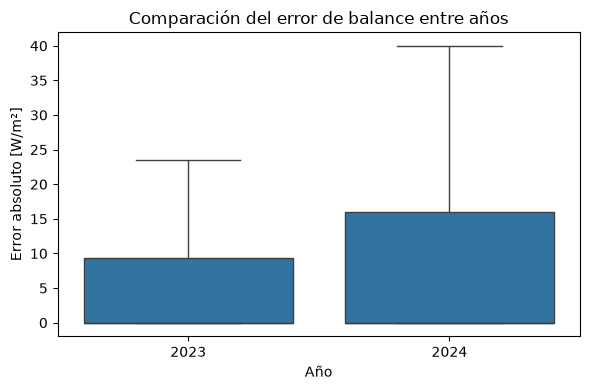

In [44]:
data_plot = df[
    ["ano", "error_balance_abs"]
].dropna()

limite = data_plot["error_balance_abs"].quantile(0.99)

plt.figure(figsize=(6, 4))

sns.boxplot(
    data=data_plot[
        data_plot["error_balance_abs"] <= limite
    ],
    x="ano",
    y="error_balance_abs",
    showfliers=False
)

plt.xlabel("Año")
plt.ylabel("Error absoluto [W/m²]")
plt.title("Comparación del error de balance entre años")
plt.tight_layout()
plt.show()

## Comparación del error de balance entre 2023 y 2024

* En **2023**, el error absoluto medio es de **60,89 W/m²**, mientras que en **2024** disminuye hasta **24,43 W/m²**, lo que representa una reducción aproximada del **59,87 %**.

* La dispersión también disminuye considerablemente. La desviación estándar pasa de **200,62 W/m²** en 2023 a **75,84 W/m²** en 2024. Esta diferencia se concentra especialmente en la cola superior, ya que el percentil 95 desciende de **527,11** a **107,48 W/m²**.

* El error firmado medio pasa de **−52,71 W/m²** en 2023 a **−2,09 W/m²** en 2024. Por tanto, los episodios en los que la `GHI` reconstruida supera considerablemente a la medida se concentran principalmente en 2023.

* La mediana del error absoluto es de **0,06 W/m²** en 2023 y de **0 W/m²** en 2024. En consecuencia, el registro típico presenta un cierre prácticamente exacto en ambos años y las diferencias interanuales se deben principalmente a episodios concretos de gran magnitud.

En conjunto, **2023 presenta errores de balance más severos y una cola de valores extremos considerablemente mayor que 2024**. Esta diferencia no demuestra por sí sola un cambio general en la calidad de los sensores, ya que puede estar provocada por periodos temporales concretos que deben localizarse y analizarse individualmente.

In [45]:
df["mes"] = df["fecha"].dt.month
df["hora"] = df["fecha"].dt.hour

error_por_hora = (
    df.groupby("hora")["error_balance_abs"]
    .agg(
        media="mean",
        mediana="median",
        percentil_90=lambda x: x.quantile(0.90),
        cantidad="count"
    )
    .reset_index()
)

error_por_hora

,hora,media,mediana,percentil_90,cantidad
0,0,0.000000,0.000000,0.000000,43560
1,1,0.000000,0.000000,0.000000,43560
2,2,0.000000,0.000000,0.000000,43560
3,3,0.000000,0.000000,0.000000,43560
4,4,0.014713,0.000000,0.000000,43560
5,5,3.586654,0.000000,2.947176,43531
6,6,15.745615,0.449649,32.228455,43226
7,7,39.263226,3.173373,98.001646,43140
8,8,66.776395,10.155087,185.711891,43140
9,9,88.189795,14.902705,237.214015,43130


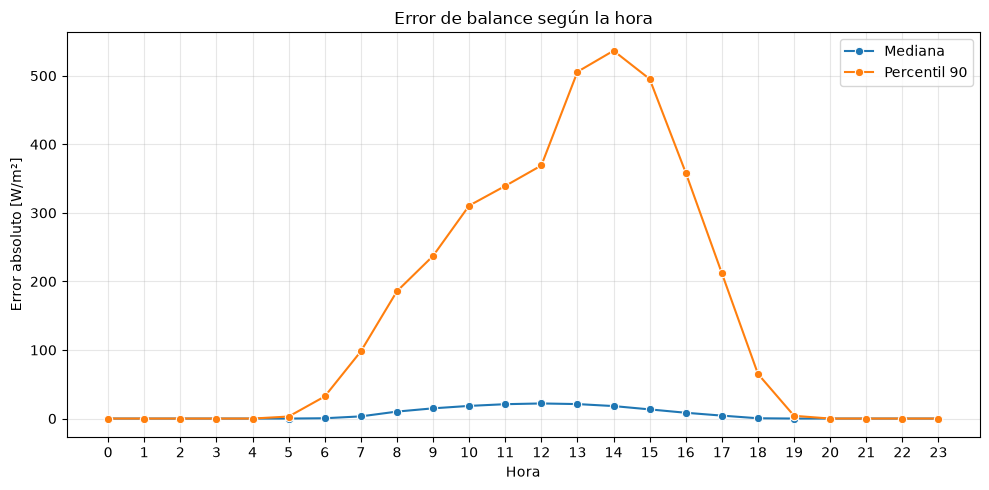

In [46]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=error_por_hora,
    x="hora",
    y="mediana",
    marker="o",
    label="Mediana"
)

sns.lineplot(
    data=error_por_hora,
    x="hora",
    y="percentil_90",
    marker="o",
    label="Percentil 90"
)

plt.xticks(range(24))
plt.xlabel("Hora")
plt.ylabel("Error absoluto [W/m²]")
plt.title("Error de balance según la hora")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [47]:
error_por_mes = (
    df.groupby("mes")["error_balance_abs"]
    .agg(
        media="mean",
        mediana="median",
        percentil_90=lambda x: x.quantile(0.90),
        cantidad="count"
    )
    .reset_index()
)

error_por_mes

,mes,media,mediana,percentil_90,cantidad
0,1,2.919432,0.000000,8.662325,89280
1,2,2.813969,0.000000,10.077147,82080
2,3,4.398033,0.000000,12.156766,79702
3,4,59.434813,0.000000,76.073270,85961
4,5,205.479147,8.184730,811.287205,89265
5,6,69.124441,4.628421,206.863854,86379
6,7,27.400531,1.692298,74.543050,89276
7,8,87.038326,6.085876,330.114978,89272
8,9,21.539493,0.000000,35.975126,86400
9,10,10.677566,0.000000,27.724583,89266


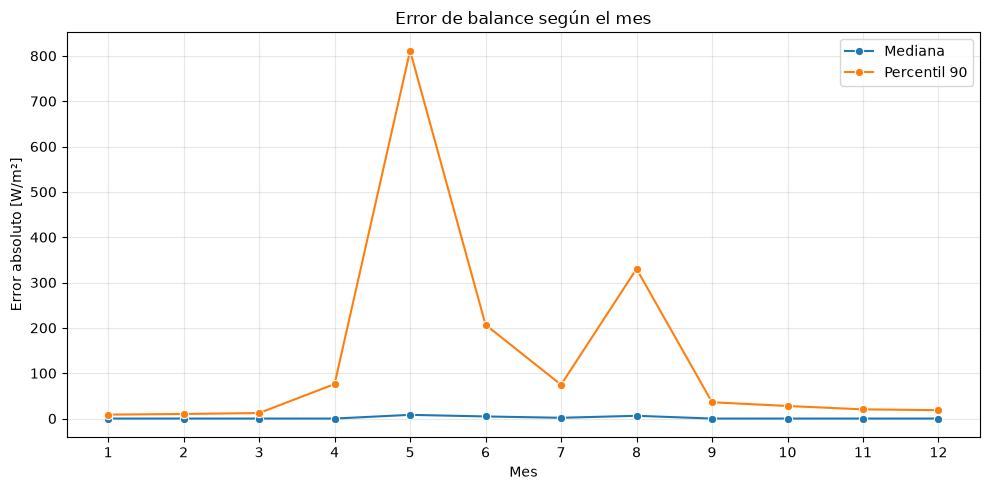

In [48]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=error_por_mes,
    x="mes",
    y="mediana",
    marker="o",
    label="Mediana"
)

sns.lineplot(
    data=error_por_mes,
    x="mes",
    y="percentil_90",
    marker="o",
    label="Percentil 90"
)

plt.xticks(range(1, 13))
plt.xlabel("Mes")
plt.ylabel("Error absoluto [W/m²]")
plt.title("Error de balance según el mes")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Evolución horaria y mensual del error de balance

* **Evolución horaria**: al agrupar todos los registros por hora, los errores son prácticamente nulos entre las **00:00 y las 04:00** y entre las **20:00 y las 23:00**. El error comienza a aumentar entre las **05:00 y las 06:00** y alcanza sus valores más elevados entre las **11:00 y las 15:00**. Debido a la variación estacional del amanecer y el atardecer, una misma hora puede contener registros diurnos y nocturnos según el mes.

* El error absoluto medio alcanza su máximo a las **13:00**, con **117,53 W/m²**, mientras que el percentil 90 alcanza su máximo a las **14:00**, con **536,52 W/m²**. Sin embargo, la mediana horaria no supera aproximadamente los **22 W/m²**, por lo que los valores elevados se concentran en una proporción limitada de observaciones.

* El patrón horario sigue aproximadamente la evolución diaria de la irradiancia. Como se está utilizando un error absoluto, su magnitud puede aumentar cuando los niveles de radiación son mayores. Por tanto, el incremento durante las horas centrales no implica necesariamente un aumento proporcional del error relativo.

* **Evolución mensual**: los resultados mensuales agrupan conjuntamente los mismos meses de 2023 y 2024. Enero, febrero y marzo presentan errores medios inferiores a **4,40 W/m²** y medianas nulas. En abril aparece un incremento considerable y mayo presenta el valor más elevado, con un error absoluto medio de **205,48 W/m²** y un percentil 90 de **811,29 W/m²**.

* Junio también presenta un error elevado, con una media de **69,12 W/m²**. En agosto aparece un segundo máximo, con una media de **87,04 W/m²** y un percentil 90 de **330,11 W/m²**. A partir de septiembre los valores disminuyen progresivamente.

El error de balance no se distribuye uniformemente en el tiempo, sino que se concentra en las horas centrales y en determinados meses. No obstante, como los meses de ambos años están agrupados, estos resultados no permiten determinar si los máximos proceden de 2023, de 2024 o de ambos años.

In [49]:
error_periodo = (
    df.groupby("periodo_solar")
    .agg(
        registros=("error_balance_abs", "count"),
        error_medio=("error_balance", "mean"),
        error_mediano=("error_balance", "median"),
        error_abs_medio=("error_balance_abs", "mean"),
        error_abs_mediano=("error_balance_abs", "median"),
        error_abs_p90=(
            "error_balance_abs",
            lambda x: x.quantile(0.90)
        ),
        error_abs_p95=(
            "error_balance_abs",
            lambda x: x.quantile(0.95)
        )
    )
)

error_periodo

,registros,error_medio,error_mediano,error_abs_medio,error_abs_mediano,error_abs_p90,error_abs_p95
periodo_solar,,,,,,,
dia,524610,-54.781267,2.526571,84.772959,12.657817,239.49523,581.376675
noche,516162,0.094751,0.000000,0.101012,0.000000,0.00000,0.000000


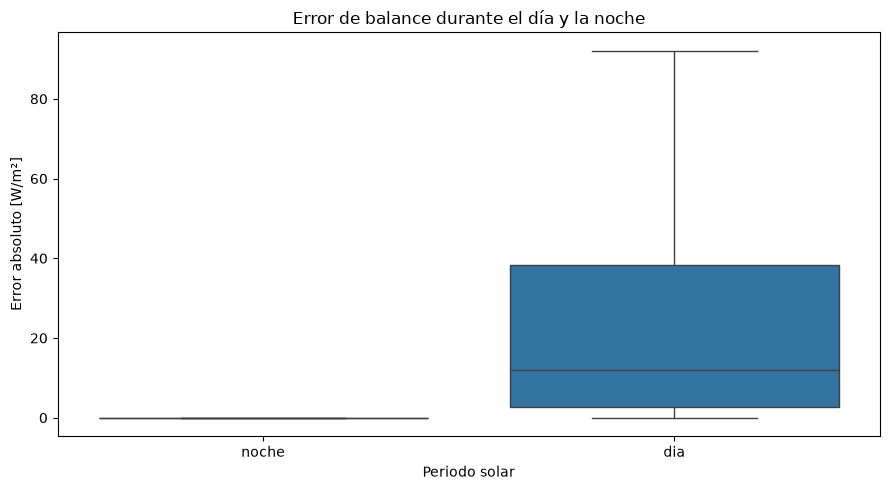

In [50]:
data_plot = df[
    ["periodo_solar", "error_balance_abs"]
].dropna()

limite = data_plot["error_balance_abs"].quantile(0.99)

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=data_plot[
        data_plot["error_balance_abs"] <= limite
    ],
    x="periodo_solar",
    y="error_balance_abs",
    showfliers=False
)

plt.xlabel("Periodo solar")
plt.ylabel("Error absoluto [W/m²]")
plt.title("Error de balance durante el día y la noche")
plt.tight_layout()
plt.show()

## Error de balance durante el día y la noche

* Durante el **día**, el error absoluto medio es de **84,77 W/m²**, la mediana es de **12,66 W/m²** y los percentiles 90 y 95 alcanzan **239,50** y **581,38 W/m²**, respectivamente. Por tanto, las inconsistencias de mayor magnitud se concentran principalmente durante el periodo diurno.

* Durante la **noche**, el error absoluto medio es de solo **0,10 W/m²**, mientras que la mediana y los percentiles 90 y 95 son iguales a cero. Al haberse fijado en cero la contribución horizontal del `DNI` cuando el Sol está bajo el horizonte, el error nocturno representa principalmente las pequeñas diferencias existentes entre `GHI` y `DHI`.

* El error firmado medio durante el día es de **−54,78 W/m²**, mientras que la mediana es positiva, con **2,53 W/m²**. Esto indica que el error típico es pequeño y positivo, pero existe una cola de errores negativos de gran magnitud que desplaza la media hacia valores negativos.

La diferencia entre ambos periodos es muy elevada. Los registros nocturnos explican gran parte de la concentración global del error en cero y pueden ocultar el comportamiento de los registros diurnos. En consecuencia, las métricas globales del error de balance deben interpretarse junto con los resultados obtenidos específicamente durante el día.

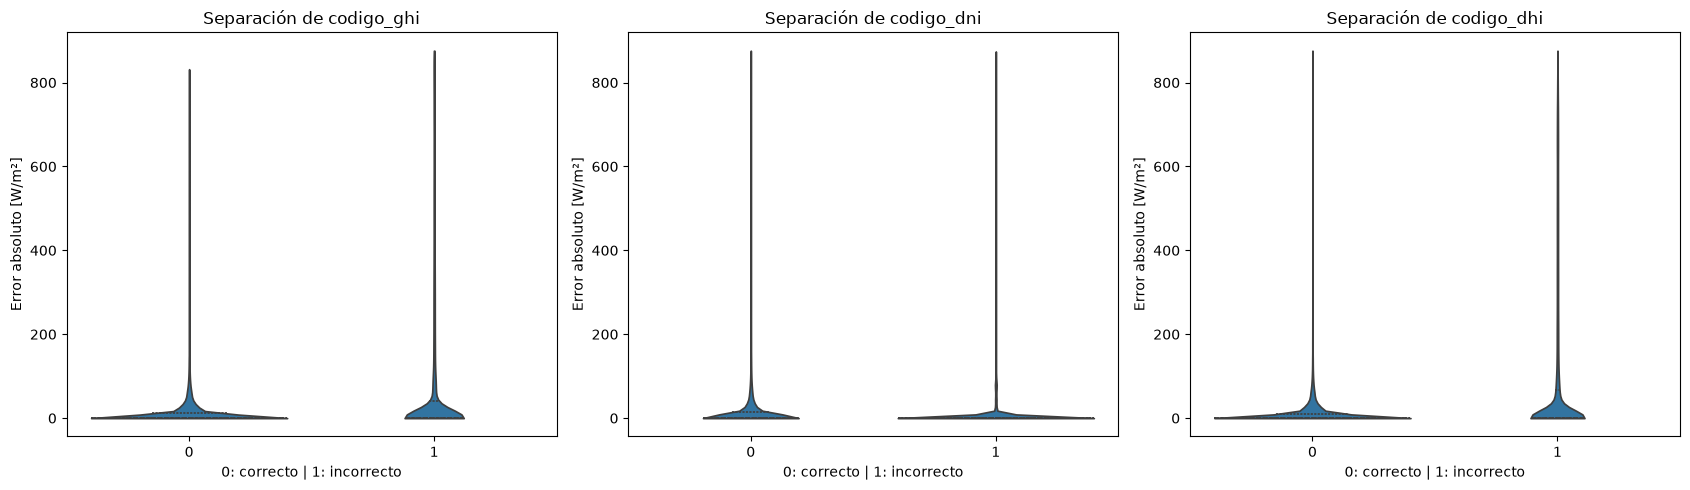

In [51]:
for target in targets:
    df[f"{target}_incorrecto"] = (
        df[target] != 0
    ).astype(int)

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(17, 5)
)

for ax, target in zip(axes, targets):
    binary_target = f"{target}_incorrecto"

    data_plot = df[
        [binary_target, "error_balance_abs"]
    ].dropna()

    limite = data_plot["error_balance_abs"].quantile(0.99)

    sns.violinplot(
        data=data_plot[
            data_plot["error_balance_abs"] <= limite
        ],
        x=binary_target,
        y="error_balance_abs",
        inner="quartile",
        cut=0,
        ax=ax
    )

    ax.set_title(f"Separación de {target}")
    ax.set_xlabel("0: correcto | 1: incorrecto")
    ax.set_ylabel("Error absoluto [W/m²]")

plt.tight_layout()
plt.show()

In [52]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
)

columnas_balance = [
    "ghi",
    "dni",
    "dhi",
    "elevacion_solar"
]

df["balance_disponible"] = (
    df[columnas_balance]
    .notna()
    .all(axis=1)
)

resultados_separacion = []

for target in targets:
    binary_target = f"{target}_incorrecto"

    data_eval = df.loc[
        df["balance_disponible"],
        [binary_target, "error_balance_abs"]
    ].dropna()

    y_true = data_eval[binary_target]
    score = data_eval["error_balance_abs"]

    if y_true.nunique() < 2:
        continue

    roc_auc = roc_auc_score(y_true, score)
    average_precision = average_precision_score(y_true, score)

    resultados_separacion.append({
        "target": target,
        "n_registros": len(data_eval),
        "tasa_incorrectos": y_true.mean(),
        "roc_auc": roc_auc,
        "average_precision_score": average_precision
    })

resultados_separacion = pd.DataFrame(
    resultados_separacion
)

resultados_separacion

,target,n_registros,tasa_incorrectos,roc_auc,average_precision_score
0,codigo_ghi,1040772,0.135361,0.514678,0.314424
1,codigo_dni,1040772,0.093375,0.310485,0.083920
2,codigo_dhi,1040772,0.173751,0.549736,0.323033


## Capacidad del error para separar códigos correctos e incorrectos

Las métricas se han calculado sobre **1.040.772 registros** en los que están disponibles `GHI`, `DNI`, `DHI` y elevación solar. Por tanto, describen la capacidad discriminante del error de balance dentro del subconjunto de casos completos y no sobre la totalidad del dataset.

La métrica calculada mediante `average_precision_score` corresponde a la **Average Precision (AP)** y no exactamente al área trapezoidal bajo la curva precision-recall.

* **Código de GHI**: el error absoluto obtiene un `ROC-AUC` de **0,515**, muy próximo al valor aleatorio de 0,5. Sin embargo, la `Average Precision` alcanza **0,314**, claramente por encima de la prevalencia de registros incorrectos, situada en el **13,54 %**. Esto indica que una parte de los códigos incorrectos se concentra en la cola de errores elevados, aunque la ordenación global de ambas clases es débil.

* **Código de DNI**: el `ROC-AUC` es de **0,310** y la `Average Precision` de **0,084**, ligeramente inferior a la prevalencia de registros incorrectos, situada en el **9,34 %**. Un `ROC-AUC` inferior a 0,5 indica una asociación inversa: los registros incorrectos tienden a presentar errores absolutos menores. Si se invirtiera la orientación del score, el `ROC-AUC` sería aproximadamente **0,690**, lo que confirma que existe cierta asociación, pero en la dirección contraria a la esperada para un indicador basado en errores elevados.

* **Código de DHI**: presenta los mejores resultados en la orientación directa. El `ROC-AUC` es de **0,550** y la `Average Precision` de **0,323**, frente a una prevalencia de registros incorrectos del **17,38 %**. Los errores extremos permiten identificar una parte de los registros incorrectos, aunque continúa existiendo un solapamiento considerable entre las clases.

En conjunto, `error_balance_abs` no permite separar por sí solo de forma fiable todos los registros correctos e incorrectos. Presenta una capacidad global débil para `GHI` y `DHI`, aunque sus valores extremos contienen información relevante. Para `DNI`, la asociación tiene una dirección inversa, por lo que un error elevado no funciona como indicador directo de una medición incorrecta.

La elevada presencia de errores nulos durante la noche puede reducir la capacidad discriminante global. Por ello, estas métricas deben interpretarse junto con una evaluación específica de los registros diurnos.

In [53]:
columns = list(df.columns)
columns

['ano',
 'mes_sin',
 'mes_cos',
 'dia',
 'hora_sin',
 'hora_cos',
 'minuto',
 'fecha',
 'ghi',
 'dni',
 'dhi',
 'elevacion_solar',
 'temperatura',
 'velocidad_viento',
 'humedad_relativa',
 'direccion_viento_sin',
 'direccion_viento_cos',
 'codigo_ghi',
 'codigo_dni',
 'codigo_dhi',
 'periodo_solar',
 'ghi_estimado',
 'error_balance',
 'error_balance_abs',
 'error_balance_rel',
 'mes',
 'hora',
 'codigo_ghi_incorrecto',
 'codigo_dni_incorrecto',
 'codigo_dhi_incorrecto',
 'balance_disponible']

In [54]:
ordered_columns = ['ano', 'mes_sin', 'mes_cos', 'dia', 'hora_sin', 'hora_cos', 'minuto', 'fecha',
 'ghi', 'dni', 'dhi', 'ghi_estimado', 'error_balance', 'error_balance_abs', 'error_balance_rel', 'elevacion_solar', 'periodo_solar',
 'temperatura', 'velocidad_viento', 'humedad_relativa', 'direccion_viento_sin', 'direccion_viento_cos',
 'codigo_ghi', 'codigo_dni', 'codigo_dhi',
 ]

df = df[ordered_columns]
df.columns

Index(['ano', 'mes_sin', 'mes_cos', 'dia', 'hora_sin', 'hora_cos', 'minuto',
       'fecha', 'ghi', 'dni', 'dhi', 'ghi_estimado', 'error_balance',
       'error_balance_abs', 'error_balance_rel', 'elevacion_solar',
       'periodo_solar', 'temperatura', 'velocidad_viento', 'humedad_relativa',
       'direccion_viento_sin', 'direccion_viento_cos', 'codigo_ghi',
       'codigo_dni', 'codigo_dhi'],
      dtype='str')